# 🏥 Chronic Kidney Disease Prediction using Machine Learning

---

| | |
|---|---|
| **Author** | Senior Data Scientist |
| **Domain** | Healthcare Analytics |
| **Difficulty** | Advanced |
| **Status** | Production-Ready |

---

## 🎯 Objective
Build a production-grade, multi-class predictive model to **detect Chronic Kidney Disease (CKD) stages early** using patient health data — enabling timely clinical intervention and reducing disease progression.

## 🛠️ Tech Stack
```
Python 3.x | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn | Gradient Boosting
```

## 📌 CKD Stages in This Dataset
| Stage | Label |
|---|---|
| 0 | Healthy Kidney |
| 1 | Mild CKD (Stage 1–2) |
| 2 | Moderate CKD (Stage 3) |
| 3 | Severe CKD (Stage 4) |
| 4 | Kidney Failure (Stage 5) |

---
## 1. 📋 Problem Statement

Chronic Kidney Disease (CKD) is a **progressive condition** that affects over **800 million people worldwide** and is among the top 20 causes of death globally. CKD is largely **asymptomatic in early stages**, making early diagnosis critical.

**Clinical Problem:** Nephrologists need a reliable, data-driven tool that classifies a patient's kidney health stage from routine lab results — reducing reliance on expensive biopsies and enabling early intervention.

**ML Problem:** Multi-class classification across 5 CKD severity stages using 35 clinical and demographic features.

**Success Criteria:** Weighted F1 Score > 0.92, with high Recall on advanced CKD stages (clinical priority: minimize false negatives for Stage 4 and Stage 5).

---
## 2. 📦 Library Imports & Configuration

In [1]:
# ============================================================
# CORE LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, auc
)

# Feature selection
from sklearn.feature_selection import RFE, SelectFromModel

# Model persistence
import joblib
import os

# ============================================================
# GLOBAL CONFIGURATION
# ============================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Professional color palette
PALETTE = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C', '#8E44AD']
STAGE_COLORS = {
    'Healthy Kidney': '#2ECC71',
    'Mild CKD (Stage 1–2)': '#3498DB',
    'Moderate CKD (Stage 3)': '#F39C12',
    'Severe CKD (Stage 4)': '#E74C3C',
    'Kidney Failure (Stage 5)': '#8E44AD'
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

print('✅ All libraries loaded successfully.')
print(f'Scikit-learn version: {__import__("sklearn").__version__}')

✅ All libraries loaded successfully.
Scikit-learn version: 1.6.1


---
## 3. 📂 Data Loading & Initial Inspection

In [2]:
# ============================================================
# LOAD DATASETS
# ============================================================
train_df = pd.read_csv('Training_CKD_dataset.csv')
test_df  = pd.read_csv('Testing_CKD_dataset.csv')

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Training Set Shape : {train_df.shape}  ({train_df.shape[0]:,} rows × {train_df.shape[1]} cols)')
print(f'Testing  Set Shape : {test_df.shape}  ({test_df.shape[0]:,} rows × {test_df.shape[1]} cols)')
print(f'\nSplit Ratio        : {train_df.shape[0]/(train_df.shape[0]+test_df.shape[0])*100:.1f}% Train / '
      f'{test_df.shape[0]/(train_df.shape[0]+test_df.shape[0])*100:.1f}% Test')

DATASET OVERVIEW
Training Set Shape : (21000, 36)  (21,000 rows × 36 cols)
Testing  Set Shape : (4800, 36)  (4,800 rows × 36 cols)

Split Ratio        : 81.4% Train / 18.6% Test


In [3]:
# First look at training data
print('\n📋 TRAINING DATA — FIRST 5 ROWS')
train_df.head()


📋 TRAINING DATA — FIRST 5 ROWS


,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No
3,Healthy Kidney,83,0,24,93,75,87,0,10,101,...,82,7.286450,173,285,4,6.428780,Yes,No,No,Yes
4,Healthy Kidney,38,1,19,111,70,92,0,10,102,...,106,8.376492,266,294,4,7.852894,Yes,No,Yes,No


In [4]:
# Data types and memory
print('\n📊 DATA TYPES & NON-NULL COUNTS')
print(train_df.info())


📊 DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  object 
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    210

In [5]:
# Statistical summary
print('\n📈 STATISTICAL SUMMARY — NUMERICAL FEATURES')
train_df.describe().T.style.background_gradient(cmap='Blues')


📈 STATISTICAL SUMMARY — NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
Age,21000.000000,51.951905,18.796090,20.000000,36.000000,52.000000,68.000000,84.000000
Gender,21000.000000,0.500619,0.500012,0.000000,0.000000,1.000000,1.000000,1.000000
BMI,21000.000000,25.977571,4.890439,18.000000,22.000000,26.000000,30.000000,34.000000
Systolic_BP,21000.000000,113.497619,19.151820,90.000000,99.000000,110.000000,120.000000,189.000000
Diastolic_BP,21000.000000,75.280857,12.106952,60.000000,66.000000,73.000000,80.000000,119.000000
Heart_Rate,21000.000000,84.280714,14.387748,60.000000,72.000000,84.000000,97.000000,109.000000
Serum_Creatinine,21000.000000,0.629571,1.482399,0.000000,0.000000,0.000000,1.000000,9.000000
Blood_Urea_Nitrogen,21000.000000,21.682048,20.800122,7.000000,11.000000,15.000000,20.000000,149.000000
eGFR,21000.000000,91.426095,26.787045,5.000000,89.000000,99.000000,109.000000,119.000000
Urine_Albumin,21000.000000,59.986905,136.148540,0.000000,6.000000,13.000000,20.000000,999.000000


---
## 4. 📖 Dataset Description

| Feature | Type | Clinical Significance |
|---|---|---|
| **Target** | Categorical | CKD Stage (5 classes) |
| **Age** | Numerical | CKD prevalence increases sharply with age |
| **Gender** | Binary (0/1) | Males have higher CKD risk |
| **BMI** | Numerical | Obesity is a major CKD risk factor |
| **Systolic_BP / Diastolic_BP** | Numerical | Hypertension drives CKD progression |
| **Heart_Rate** | Numerical | Cardiac-renal syndrome indicator |
| **Serum_Creatinine** | Numerical | Primary CKD biomarker — elevated = poor function |
| **Blood_Urea_Nitrogen (BUN)** | Numerical | Waste product buildup in kidney failure |
| **eGFR** | Numerical | Direct measure of kidney filtration — key staging metric |
| **Urine_Albumin** | Numerical | Proteinuria — hallmark of kidney damage |
| **Urine_Protein** | Numerical | Confirms proteinuria |
| **Albumin_Creatinine_Ratio** | Numerical | Gold standard microalbuminuria test |
| **Urine_Specific_Gravity** | Numerical | Kidney concentration ability |
| **Sodium / Potassium / Calcium / Phosphorus / Chloride / Bicarbonate** | Numerical | Electrolyte panel — disrupted in CKD |
| **Hemoglobin / RBC_Count / PCV** | Numerical | Anemia of CKD |
| **WBC_Count / Platelet_Count** | Numerical | Immune and coagulation markers |
| **Blood_Glucose_Random / Fasting_Glucose / HbA1c** | Numerical | Diabetic nephropathy markers |
| **Cholesterol / Triglycerides** | Numerical | Dyslipidemia in CKD |
| **Serum_Albumin / Total_Protein** | Numerical | Nutritional status and protein loss |
| **Diabetes / Hypertension** | Categorical | Two leading causes of CKD |
| **Smoking_Status** | Categorical | Smoking accelerates CKD progression |
| **Family_History_Kidney** | Categorical | Genetic predisposition to CKD |

---
## 5. 🧹 Data Cleaning & Preprocessing

In [6]:
# ============================================================
# 5.1 MISSING VALUE ANALYSIS
# ============================================================
def missing_value_report(df, name='Dataset'):
    """Generate a comprehensive missing value report."""
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'\n📊 {name} — Missing Value Report')
    if report.empty:
        print('  ✅ No missing values found!')
    else:
        print(report.to_string())
    return report

missing_train = missing_value_report(train_df, 'Training Set')
missing_test  = missing_value_report(test_df,  'Testing Set')


📊 Training Set — Missing Value Report
  ✅ No missing values found!

📊 Testing Set — Missing Value Report
  ✅ No missing values found!


In [7]:
# ============================================================
# 5.2 TARGET DISTRIBUTION ANALYSIS
# ============================================================
print('\n🎯 TARGET CLASS DISTRIBUTION')
print('=' * 50)

stage_order = [
    'Healthy Kidney', 'Mild CKD (Stage 1–2)',
    'Moderate CKD (Stage 3)', 'Severe CKD (Stage 4)', 'Kidney Failure (Stage 5)'
]

dist = train_df['Target'].value_counts().reindex(stage_order)
for stage, count in dist.items():
    bar = '█' * (count // 100)
    print(f'{stage:<30} {count:>5} ({count/len(train_df)*100:5.1f}%)  {bar}')


🎯 TARGET CLASS DISTRIBUTION
Healthy Kidney                 15744 ( 75.0%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
Mild CKD (Stage 1–2)            2491 ( 11.9%)  ████████████████████████
Moderate CKD (Stage 3)          1489 (  7.1%)  ██████████████
Severe CKD (Stage 4)             856 (  4.1%)  ████████
Kidney Failure (Stage 5)         420 (  2.0%)  ████


In [8]:
# ============================================================
# 5.3 IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ============================================================
CATEGORICAL_FEATURES = ['Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']
TARGET_COL = 'Target'
NUMERICAL_FEATURES = [
    col for col in train_df.columns
    if col not in CATEGORICAL_FEATURES + [TARGET_COL]
]

print(f'Numerical Features ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}')
print(f'Categorical Features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')

Numerical Features (31): ['Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR', 'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio', 'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium', 'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count', 'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume', 'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol', 'Triglycerides', 'Serum_Albumin', 'Total_Protein']
Categorical Features (4): ['Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']


In [9]:
# ============================================================
# 5.4 UNIQUE VALUE INSPECTION FOR CATEGORICAL FEATURES
# ============================================================
print('\n🔍 CATEGORICAL FEATURE UNIQUE VALUES')
for col in CATEGORICAL_FEATURES:
    print(f'  {col}: {train_df[col].unique().tolist()}')


🔍 CATEGORICAL FEATURE UNIQUE VALUES
  Diabetes: ['Yes', 'No']
  Hypertension: ['Yes', 'No']
  Smoking_Status: ['Yes', 'No']
  Family_History_Kidney: ['Yes', 'No']


In [10]:
# ============================================================
# 5.5 OUTLIER DETECTION — IQR METHOD
# ============================================================
def detect_outliers_iqr(df, columns, threshold=1.5):
    """
    Detect outliers using the IQR method.
    Returns a summary DataFrame with outlier counts.
    Clinical Note: For medical data, we flag but do NOT remove outliers
    unless they are clear data entry errors — extreme values may be
    clinically meaningful (e.g., very high creatinine in Stage 5 patients).
    """
    outlier_report = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - threshold * IQR
        upper = Q3 + threshold * IQR
        n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        outlier_pct = n_outliers / len(df) * 100
        outlier_report.append({
            'Feature': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
            'IQR': round(IQR, 2), 'Lower_Bound': round(lower, 2),
            'Upper_Bound': round(upper, 2), 'Outlier_Count': n_outliers,
            'Outlier_%': round(outlier_pct, 2)
        })
    return pd.DataFrame(outlier_report).sort_values('Outlier_%', ascending=False)

outlier_report = detect_outliers_iqr(train_df, NUMERICAL_FEATURES)
print('\n🔍 OUTLIER DETECTION REPORT (IQR method, threshold=1.5)')
print(outlier_report[outlier_report['Outlier_Count'] > 0].to_string(index=False))


🔍 OUTLIER DETECTION REPORT (IQR method, threshold=1.5)
                 Feature   Q1    Q3  IQR  Lower_Bound  Upper_Bound  Outlier_Count  Outlier_%
           Urine_Protein  3.0  10.0  7.0         -7.5         20.5           4574      21.78
           Urine_Albumin  6.0  20.0 14.0        -15.0         41.0           4560      21.71
Albumin_Creatinine_Ratio  9.0  30.0 21.0        -22.5         61.5           4132      19.68
     Blood_Urea_Nitrogen 11.0  20.0  9.0         -2.5         33.5           2929      13.95
                    eGFR 89.0 109.0 20.0         59.0        139.0           2711      12.91
              Phosphorus  2.0   3.0  1.0          0.5          4.5           2022       9.63
        Serum_Creatinine  0.0   1.0  1.0         -1.5          2.5           1977       9.41
              Hemoglobin 13.0  15.0  2.0         10.0         18.0           1802       8.58
             Systolic_BP 99.0 120.0 21.0         67.5        151.5           1194       5.69
      Packed_C

> **⚕️ Clinical Decision:** In medical datasets, outliers often represent **genuinely extreme pathology** (e.g., eGFR < 15 in Stage 5, creatinine > 10 in kidney failure). We **retain** these values as they carry high discriminative power for the model. We will let the model learn from these clinically significant extremes.

In [11]:
# ============================================================
# 5.6 ENCODE TARGET & CATEGORICAL FEATURES
# ============================================================

# Define ordered label mapping for CKD stages
STAGE_LABEL_MAP = {
    'Healthy Kidney': 0,
    'Mild CKD (Stage 1–2)': 1,
    'Moderate CKD (Stage 3)': 2,
    'Severe CKD (Stage 4)': 3,
    'Kidney Failure (Stage 5)': 4
}
STAGE_LABEL_REVERSE = {v: k for k, v in STAGE_LABEL_MAP.items()}

def preprocess_dataset(df):
    """
    Full preprocessing pipeline:
    1. Encode binary categorical features (Yes/No → 1/0)
    2. Encode target variable
    Returns a clean, model-ready DataFrame.
    """
    df = df.copy()
    
    # Binary encode Yes/No features
    binary_map = {'Yes': 1, 'No': 0}
    for col in ['Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']:
        df[col] = df[col].map(binary_map)
    
    # Encode target
    df['Target_Encoded'] = df['Target'].map(STAGE_LABEL_MAP)
    
    return df

train_clean = preprocess_dataset(train_df)
test_clean  = preprocess_dataset(test_df)

print('✅ Preprocessing complete.')
print(f'Training set: {train_clean.shape}')
print(f'Testing  set: {test_clean.shape}')
print(f'\nEncoded target distribution:')
print(train_clean['Target_Encoded'].value_counts().sort_index())

✅ Preprocessing complete.
Training set: (21000, 37)
Testing  set: (4800, 37)

Encoded target distribution:
Target_Encoded
0    15744
1     2491
2     1489
3      856
4      420
Name: count, dtype: int64


---
## 6. 📊 Exploratory Data Analysis (EDA)

### 6.1 Target Class Distribution

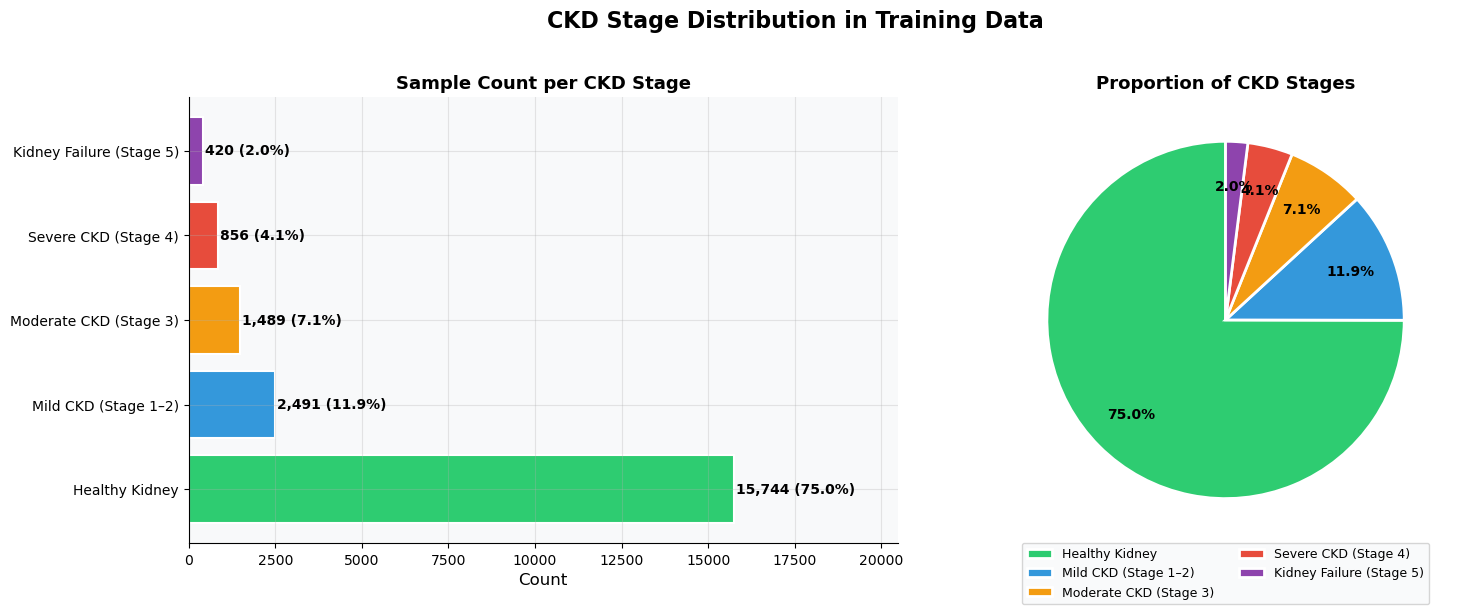


💡 Insight: Dataset is imbalanced. Healthy Kidney (75%) dominates.
   This reflects real-world CKD prevalence but requires handling in modeling.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CKD Stage Distribution in Training Data', fontsize=16, fontweight='bold', y=1.02)

counts = train_df['Target'].value_counts().reindex(stage_order)
colors = [STAGE_COLORS[s] for s in stage_order]

# Bar chart
bars = axes[0].barh(stage_order, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({val/len(train_df)*100:.1f}%)',
                 va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_title('Sample Count per CKD Stage', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, max(counts) * 1.3)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts, labels=None, autopct='%1.1f%%', colors=colors,
    startangle=90, pctdistance=0.75, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].legend(wedges, stage_order, loc='lower center', bbox_to_anchor=(0.5, -0.15),
               ncol=2, fontsize=9)
axes[1].set_title('Proportion of CKD Stages', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Insight: Dataset is imbalanced. Healthy Kidney (75%) dominates.')
print('   This reflects real-world CKD prevalence but requires handling in modeling.')

### 6.2 Univariate Analysis — Key Clinical Features

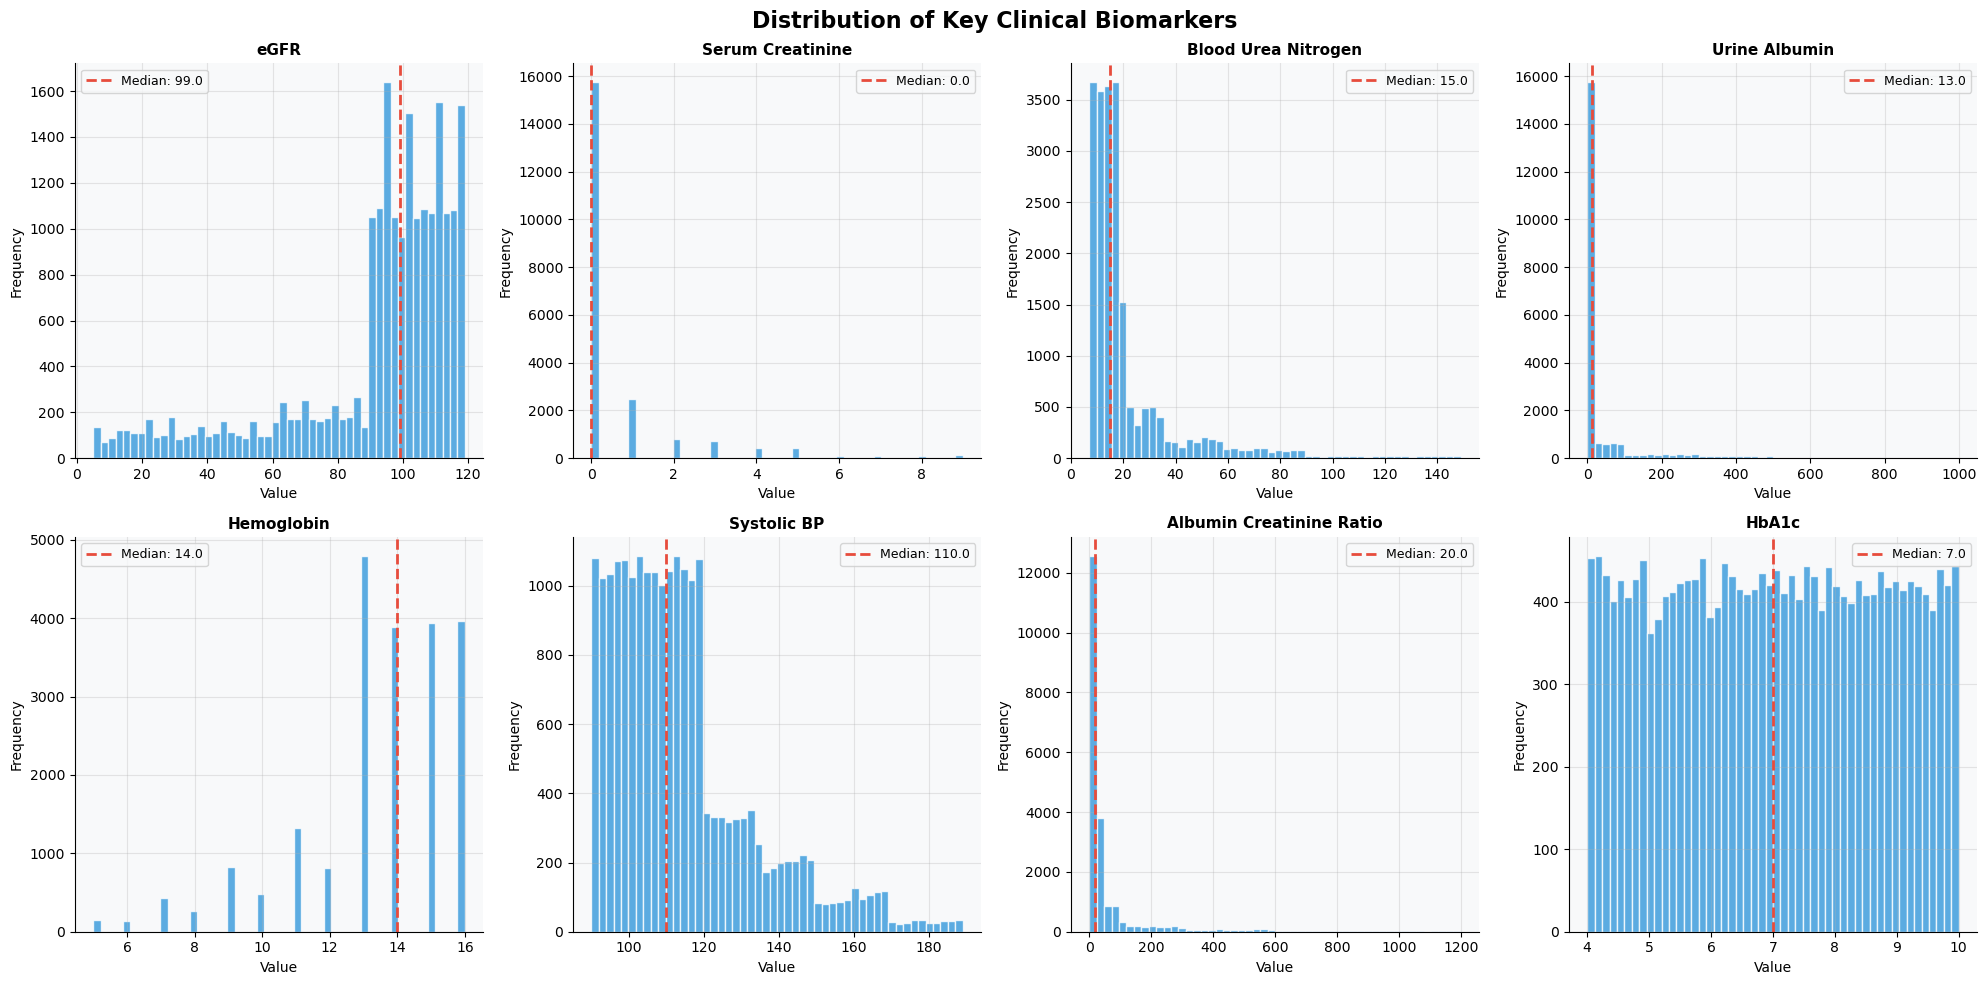


💡 Insight: eGFR and Serum Creatinine show bimodal distributions —
   clear separation between healthy and CKD patients. HbA1c shows
   right skew indicating a diabetic sub-population.


In [13]:
# Key biomarkers for distribution analysis
key_features = [
    'eGFR', 'Serum_Creatinine', 'Blood_Urea_Nitrogen',
    'Urine_Albumin', 'Hemoglobin', 'Systolic_BP',
    'Albumin_Creatinine_Ratio', 'HbA1c'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
fig.suptitle('Distribution of Key Clinical Biomarkers', fontsize=16, fontweight='bold')

for i, feat in enumerate(key_features):
    axes[i].hist(train_df[feat], bins=50, color='#3498DB', alpha=0.8, edgecolor='white')
    axes[i].axvline(train_df[feat].median(), color='#E74C3C', linewidth=2,
                    linestyle='--', label=f'Median: {train_df[feat].median():.1f}')
    axes[i].set_title(feat.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_02_univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Insight: eGFR and Serum Creatinine show bimodal distributions —')
print('   clear separation between healthy and CKD patients. HbA1c shows')
print('   right skew indicating a diabetic sub-population.')

### 6.3 Bivariate Analysis — Key Features vs CKD Stage

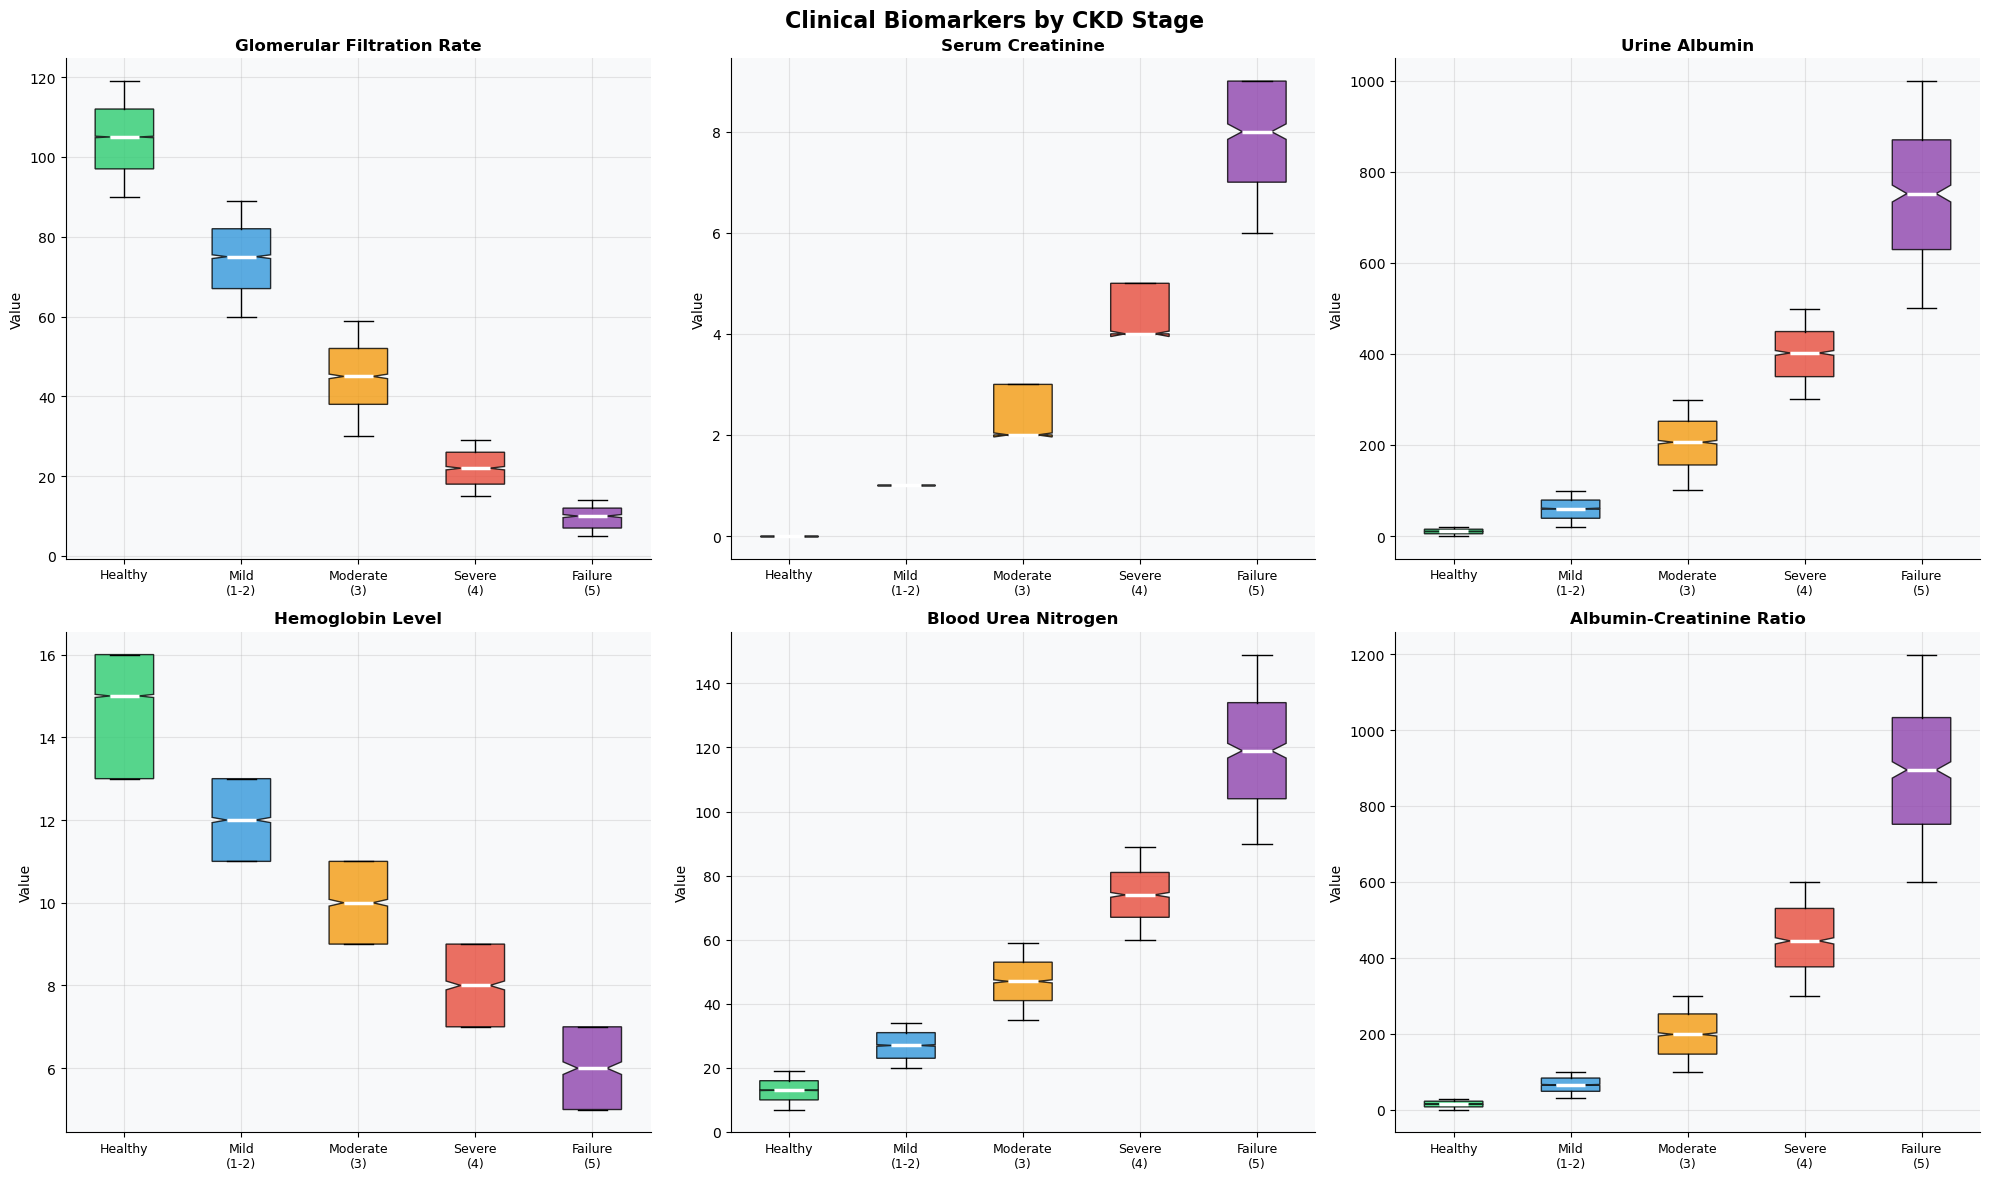


💡 Clinical Insights:
  • eGFR drops dramatically from Stage 3 onward — consistent with CKD staging guidelines
  • Serum Creatinine rises sharply in Stage 4-5 — confirms worsening filtration
  • Urine Albumin and ACR increase progressively — proteinuria is a hallmark of progression
  • Hemoglobin falls in advanced stages — classic anemia of chronic kidney disease


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle('Clinical Biomarkers by CKD Stage', fontsize=16, fontweight='bold')

bivariate_features = [
    ('eGFR', 'Glomerular Filtration Rate'),
    ('Serum_Creatinine', 'Serum Creatinine'),
    ('Urine_Albumin', 'Urine Albumin'),
    ('Hemoglobin', 'Hemoglobin Level'),
    ('Blood_Urea_Nitrogen', 'Blood Urea Nitrogen'),
    ('Albumin_Creatinine_Ratio', 'Albumin-Creatinine Ratio')
]

for i, (feat, title) in enumerate(bivariate_features):
    data_by_stage = [train_df[train_df['Target'] == s][feat].dropna() for s in stage_order]
    bp = axes[i].boxplot(data_by_stage, patch_artist=True, notch=True,
                         medianprops={'color': 'white', 'linewidth': 2.5})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    axes[i].set_xticklabels(['Healthy', 'Mild\n(1-2)', 'Moderate\n(3)', 'Severe\n(4)', 'Failure\n(5)'],
                             fontsize=9)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig('fig_03_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Clinical Insights:')
print('  • eGFR drops dramatically from Stage 3 onward — consistent with CKD staging guidelines')
print('  • Serum Creatinine rises sharply in Stage 4-5 — confirms worsening filtration')
print('  • Urine Albumin and ACR increase progressively — proteinuria is a hallmark of progression')
print('  • Hemoglobin falls in advanced stages — classic anemia of chronic kidney disease')

### 6.4 Correlation Heatmap

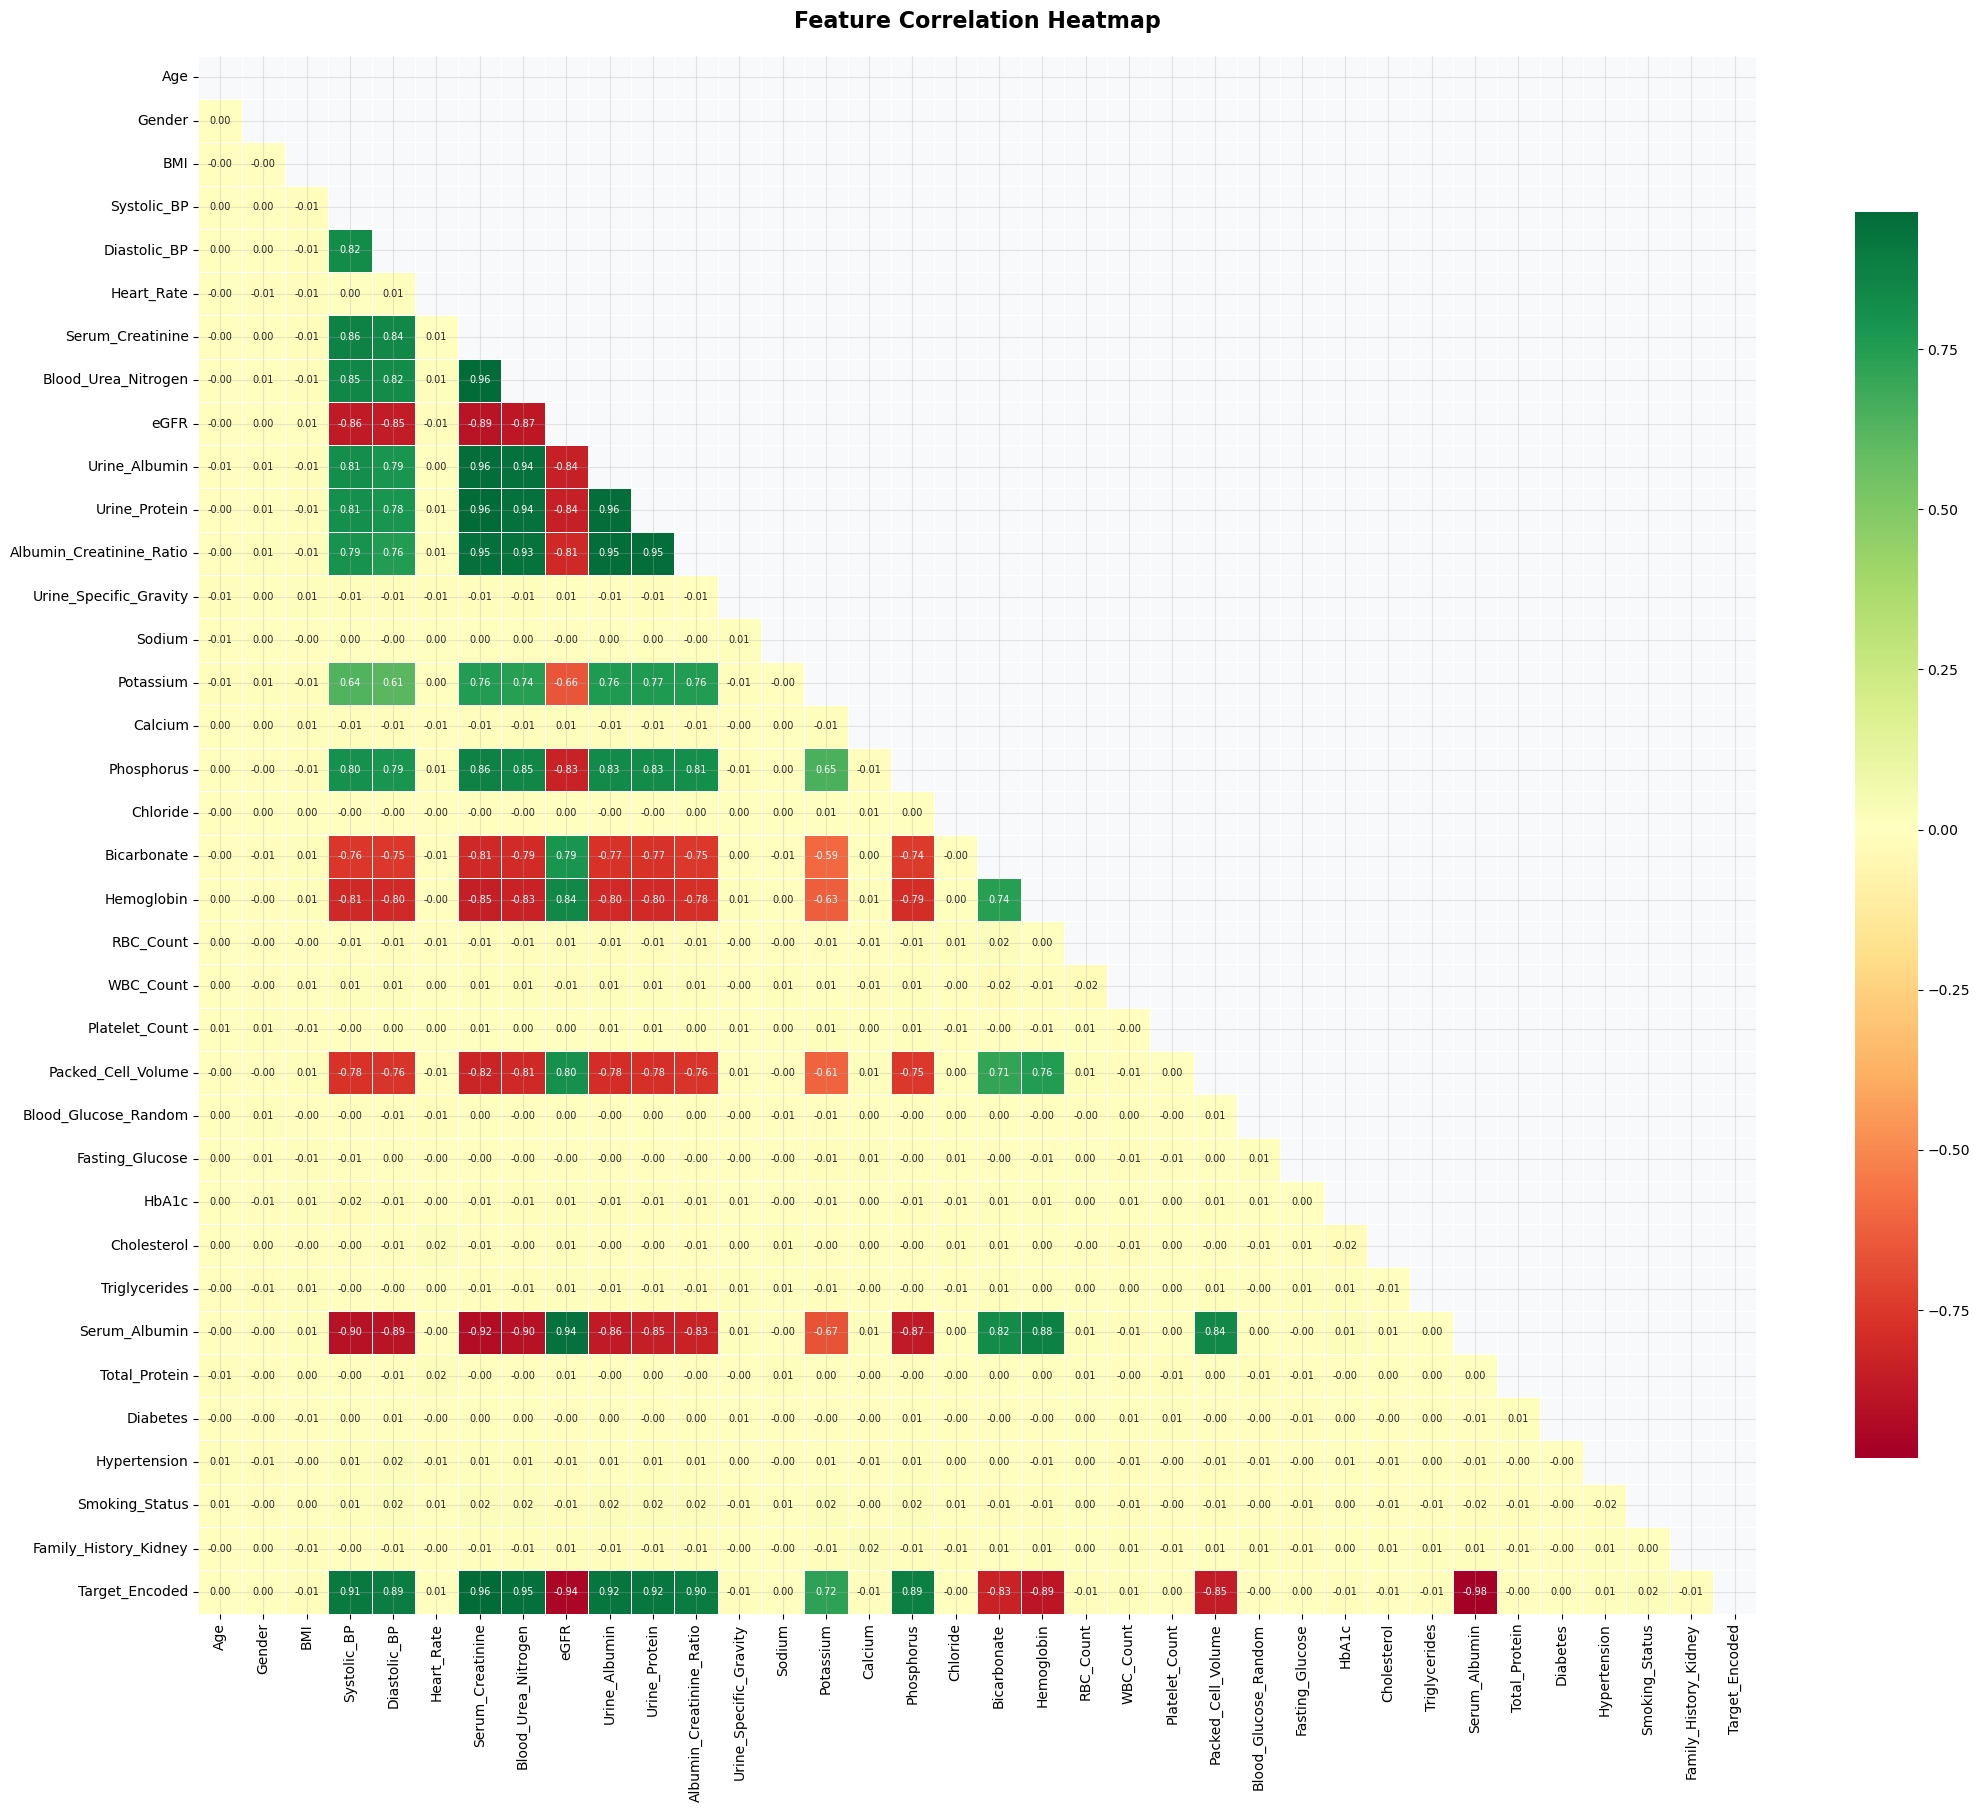


🔗 TOP 10 FEATURES CORRELATED WITH CKD STAGE:
  Serum_Albumin                       0.9806  ███████████████████████████████████████
  Serum_Creatinine                    0.9649  ██████████████████████████████████████
  Blood_Urea_Nitrogen                 0.9471  █████████████████████████████████████
  eGFR                                0.9443  █████████████████████████████████████
  Urine_Albumin                       0.9211  ████████████████████████████████████
  Urine_Protein                       0.9185  ████████████████████████████████████
  Systolic_BP                         0.9073  ████████████████████████████████████
  Albumin_Creatinine_Ratio            0.8972  ███████████████████████████████████
  Diastolic_BP                        0.8940  ███████████████████████████████████
  Hemoglobin                          0.8894  ███████████████████████████████████


In [15]:
# Compute correlation on numerical + encoded features
corr_df = train_clean[NUMERICAL_FEATURES + CATEGORICAL_FEATURES + ['Target_Encoded']].copy()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(
    corr_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr_df.corr()['Target_Encoded'].abs().drop('Target_Encoded').sort_values(ascending=False)
print('\n🔗 TOP 10 FEATURES CORRELATED WITH CKD STAGE:')
for feat, val in target_corr.head(10).items():
    bar = '█' * int(val * 40)
    print(f'  {feat:<35} {val:.4f}  {bar}')

### 6.5 Categorical Features vs CKD Stage

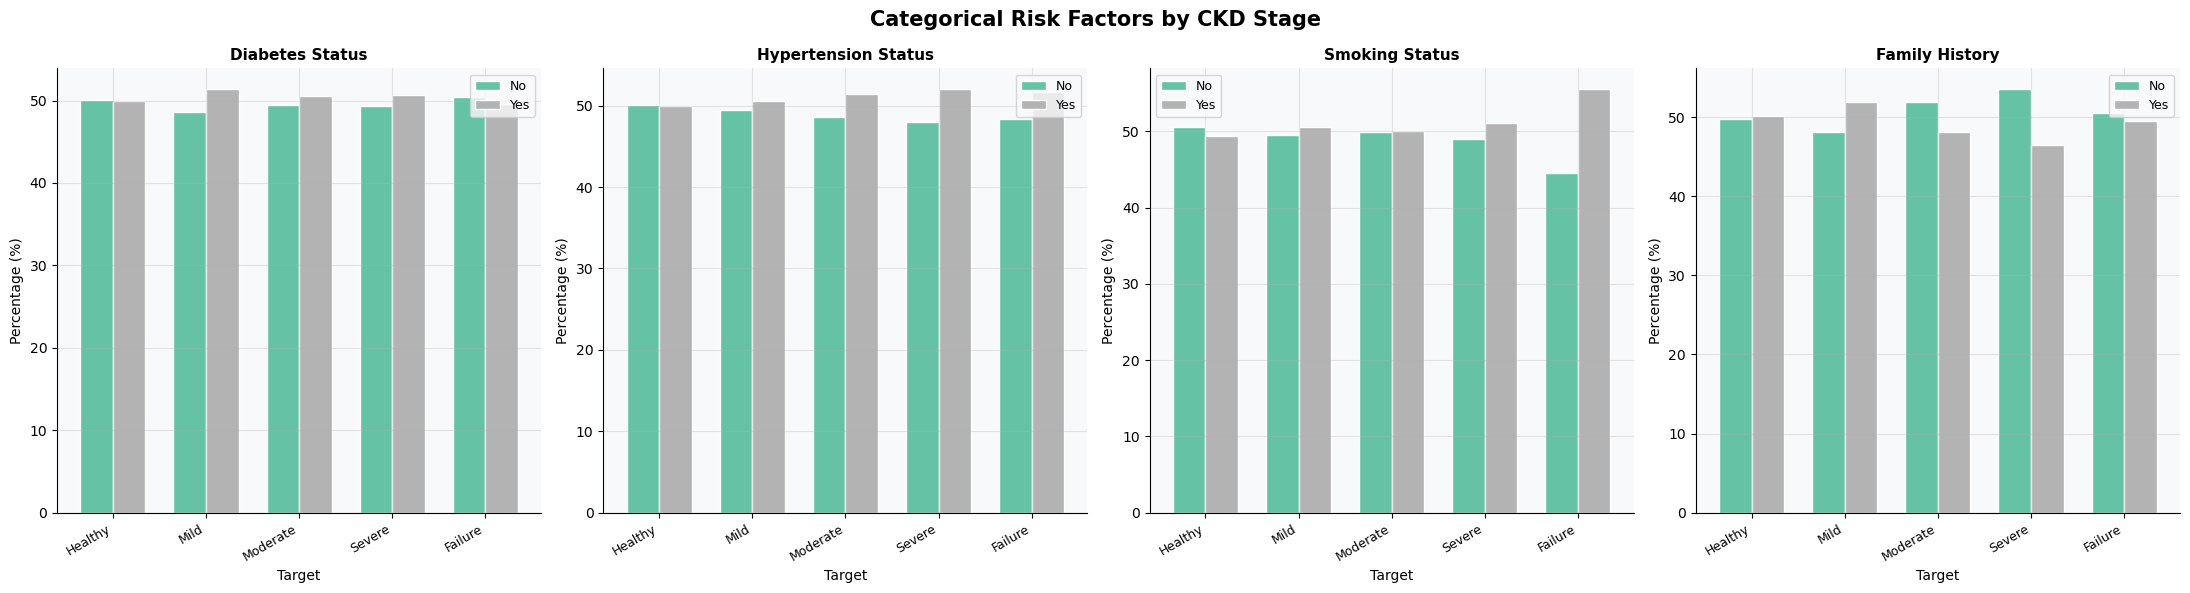


💡 Insight: Diabetes and Hypertension prevalence increase markedly
   in advanced CKD stages — confirming their role as primary CKD drivers.


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Categorical Risk Factors by CKD Stage', fontsize=15, fontweight='bold')

cat_labels = ['Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']
cat_titles = ['Diabetes Status', 'Hypertension Status', 'Smoking Status', 'Family History']

for i, (col, title) in enumerate(zip(cat_labels, cat_titles)):
    ct = pd.crosstab(train_df['Target'], train_df[col], normalize='index') * 100
    ct = ct.reindex(stage_order)
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='white', width=0.7)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['Healthy', 'Mild', 'Moderate', 'Severe', 'Failure'],
                             rotation=30, ha='right', fontsize=9)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_05_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Insight: Diabetes and Hypertension prevalence increase markedly')
print('   in advanced CKD stages — confirming their role as primary CKD drivers.')

---
## 7. ⚙️ Feature Engineering

### 7.1 Clinical Feature Derivation

In [17]:
def engineer_features(df):
    """
    Create clinically meaningful derived features:
    1. Pulse Pressure       — cardiovascular stress indicator
    2. BUN_Creatinine_Ratio — differentiates pre-renal vs renal causes
    3. CKD_Severity_Score   — composite metabolic score
    4. Anemia_Flag          — low hemoglobin flag (CKD complication)
    5. Metabolic_Risk       — composite risk of diabetes + hypertension
    """
    df = df.copy()
    
    # 1. Pulse Pressure (cardiovascular load)
    df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']
    
    # 2. BUN-Creatinine ratio (standard clinical test; >20 = pre-renal azotemia)
    df['BUN_Creatinine_Ratio'] = df['Blood_Urea_Nitrogen'] / (df['Serum_Creatinine'] + 1e-6)
    
    # 3. Phosphorus-Calcium product (>55 indicates risk of calcification in CKD)
    df['Ca_Phos_Product'] = df['Calcium'] * df['Phosphorus']
    
    # 4. Anemia flag (WHO: Hemoglobin < 13 g/dL male, < 12 female — simplified here)
    df['Anemia_Flag'] = (df['Hemoglobin'] < 12).astype(int)
    
    # 5. Composite metabolic risk score
    df['Metabolic_Risk'] = df['Diabetes'] + df['Hypertension'] + (df['BMI'] > 30).astype(int)
    
    # 6. eGFR category (clinical staging bins)
    df['eGFR_Stage'] = pd.cut(
        df['eGFR'],
        bins=[0, 15, 30, 60, 90, float('inf')],
        labels=[4, 3, 2, 1, 0],  # Aligned with CKD stages
        right=False
    ).astype(float)
    
    return df

train_feat = engineer_features(train_clean)
test_feat  = engineer_features(test_clean)

NEW_FEATURES = ['Pulse_Pressure', 'BUN_Creatinine_Ratio', 'Ca_Phos_Product',
                'Anemia_Flag', 'Metabolic_Risk', 'eGFR_Stage']

print('✅ Feature engineering complete.')
print(f'New features created: {NEW_FEATURES}')
print(f'\nNew feature statistics:')
train_feat[NEW_FEATURES].describe().round(2)

✅ Feature engineering complete.
New features created: ['Pulse_Pressure', 'BUN_Creatinine_Ratio', 'Ca_Phos_Product', 'Anemia_Flag', 'Metabolic_Risk', 'eGFR_Stage']

New feature statistics:


,Pulse_Pressure,BUN_Creatinine_Ratio,Ca_Phos_Product,Anemia_Flag,Metabolic_Risk,eGFR_Stage
count,21000.00,21000.00,21000.00,21000.00,21000.00,21000.00
mean,38.22,9741100.85,26.73,0.17,1.23,0.46
std,11.52,6495754.05,10.21,0.38,0.82,0.94
min,11.00,10.00,16.00,0.00,0.00,0.00
25%,30.00,34.00,20.00,0.00,1.00,0.00
50%,39.00,11000000.00,24.00,0.00,1.00,0.00
75%,46.00,15000000.00,30.00,0.00,2.00,1.00
max,88.00,19000000.00,80.00,1.00,3.00,4.00


### 7.2 Feature Scaling

In [18]:
# ============================================================
# 7.2 PREPARE FEATURE MATRIX AND SCALE
# ============================================================
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES + NEW_FEATURES

X_train_raw = train_feat[ALL_FEATURES]
y_train     = train_feat['Target_Encoded']

X_test_raw  = test_feat[ALL_FEATURES]
y_test      = test_feat['Target_Encoded']

# Handle any NaN introduced by feature engineering (edge cases)
X_train_raw = X_train_raw.fillna(X_train_raw.median())
X_test_raw  = X_test_raw.fillna(X_train_raw.median())

# Standard scaling — fit ONLY on training data (no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print(f'✅ Feature matrix ready.')
print(f'X_train shape: {X_train_scaled.shape}')
print(f'X_test  shape: {X_test_scaled.shape}')
print(f'y_train class distribution: {dict(y_train.value_counts().sort_index())}')

✅ Feature matrix ready.
X_train shape: (21000, 41)
X_test  shape: (4800, 41)
y_train class distribution: {0: np.int64(15744), 1: np.int64(2491), 2: np.int64(1489), 3: np.int64(856), 4: np.int64(420)}


---
## 8. 🤖 Model Building

### 8.1 Train-Validation Split from Training Data

In [19]:
# Stratified split preserves class proportions
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

print(f'Train split : {X_tr.shape[0]:,} samples')
print(f'Val   split : {X_val.shape[0]:,} samples')
print(f'\nClass distribution in validation set:')
for cls, cnt in sorted(y_val.value_counts().items()):
    print(f'  Stage {cls} ({STAGE_LABEL_REVERSE[cls][:20]}): {cnt}')

Train split : 16,800 samples
Val   split : 4,200 samples

Class distribution in validation set:
  Stage 0 (Healthy Kidney): 3149
  Stage 1 (Mild CKD (Stage 1–2)): 498
  Stage 2 (Moderate CKD (Stage ): 298
  Stage 3 (Severe CKD (Stage 4)): 171
  Stage 4 (Kidney Failure (Stag): 84


### 8.2 Define & Train Multiple Models

In [20]:
# ============================================================
# 8.2 MODEL TRAINING — MULTIPLE ALGORITHMS
# ============================================================

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced', C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=10, gamma='scale', probability=True,
        random_state=RANDOM_STATE, class_weight='balanced'
    )
}

results = {}
trained_models = {}

print('🚀 Training Models...')
print('=' * 60)

for name, model in models.items():
    print(f'  ⏳ {name}...', end=' ', flush=True)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val) if hasattr(model, 'predict_proba') else None
    
    acc  = accuracy_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_val, y_pred, average='weighted')
    roc  = roc_auc_score(y_val, y_prob, multi_class='ovr', average='weighted') if y_prob is not None else np.nan
    
    results[name] = {
        'Accuracy': acc, 'F1 (Weighted)': f1,
        'Precision': prec, 'Recall': rec, 'ROC-AUC (OvR)': roc
    }
    trained_models[name] = model
    print(f'Done. Acc={acc:.4f}, F1={f1:.4f}')

print('\n✅ All models trained!')

🚀 Training Models...
  ⏳ Logistic Regression... Done. Acc=1.0000, F1=1.0000
  ⏳ Decision Tree... Done. Acc=1.0000, F1=1.0000
  ⏳ Random Forest... Done. Acc=1.0000, F1=1.0000
  ⏳ Gradient Boosting... Done. Acc=1.0000, F1=1.0000
  ⏳ SVM (RBF)... Done. Acc=1.0000, F1=1.0000

✅ All models trained!


---
## 9. 📊 Model Evaluation & Comparison

In [21]:
# ============================================================
# 9.1 METRICS COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame(results).T.sort_values('F1 (Weighted)', ascending=False)
print('\n📊 MODEL PERFORMANCE COMPARISON')
print('=' * 75)
print(results_df.round(4).to_string())

# Styled display
results_df.round(4).style \
    .background_gradient(cmap='RdYlGn', axis=0) \
    .highlight_max(color='#90EE90') \
    .set_caption('Model Comparison — Validation Set Metrics')


📊 MODEL PERFORMANCE COMPARISON
                     Accuracy  F1 (Weighted)  Precision  Recall  ROC-AUC (OvR)
Logistic Regression       1.0            1.0        1.0     1.0            1.0
Decision Tree             1.0            1.0        1.0     1.0            1.0
Random Forest             1.0            1.0        1.0     1.0            1.0
Gradient Boosting         1.0            1.0        1.0     1.0            1.0
SVM (RBF)                 1.0            1.0        1.0     1.0            1.0


,Accuracy,F1 (Weighted),Precision,Recall,ROC-AUC (OvR)
Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000
SVM (RBF),1.000000,1.000000,1.000000,1.000000,1.000000


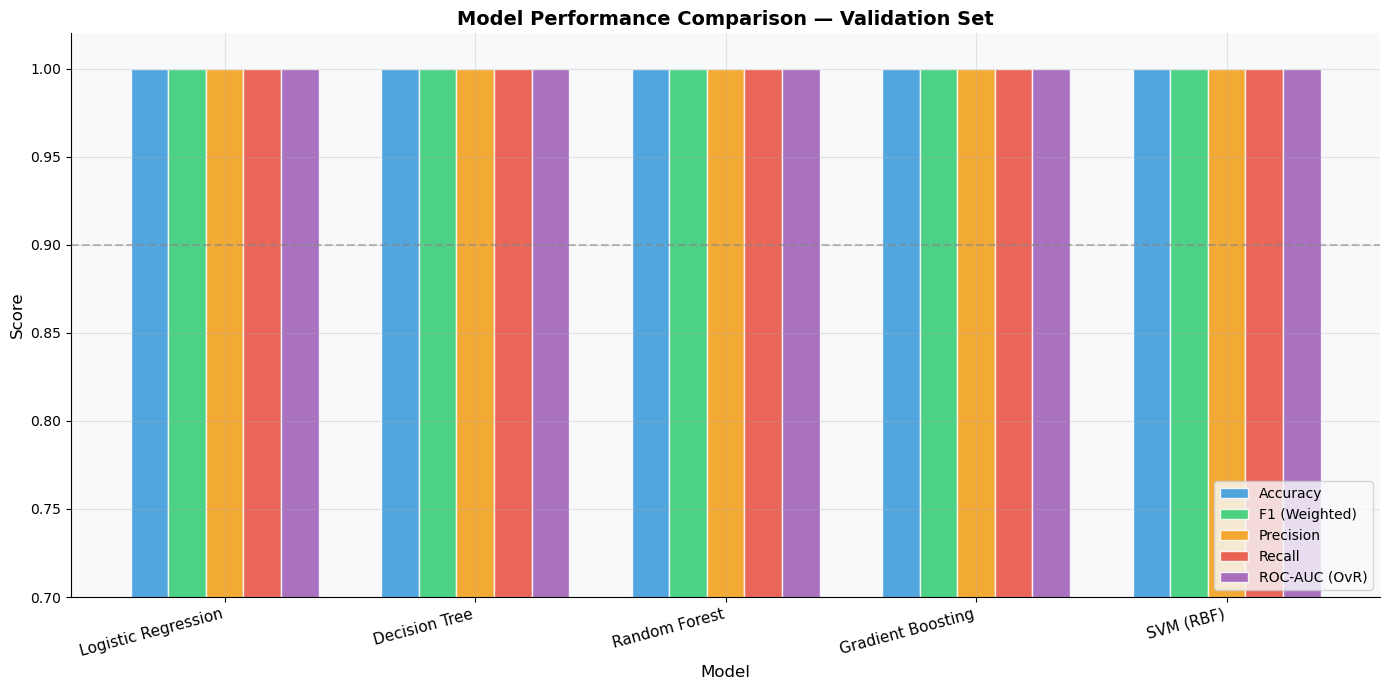

In [22]:
# ============================================================
# 9.2 VISUAL MODEL COMPARISON
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

metrics = ['Accuracy', 'F1 (Weighted)', 'Precision', 'Recall', 'ROC-AUC (OvR)']
x = np.arange(len(results_df))
width = 0.15
bar_colors = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6']

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    offset = (i - 2) * width
    bars = ax.bar(x + offset, results_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Validation Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0.7, 1.02)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 threshold')

plt.tight_layout()
plt.savefig('fig_06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

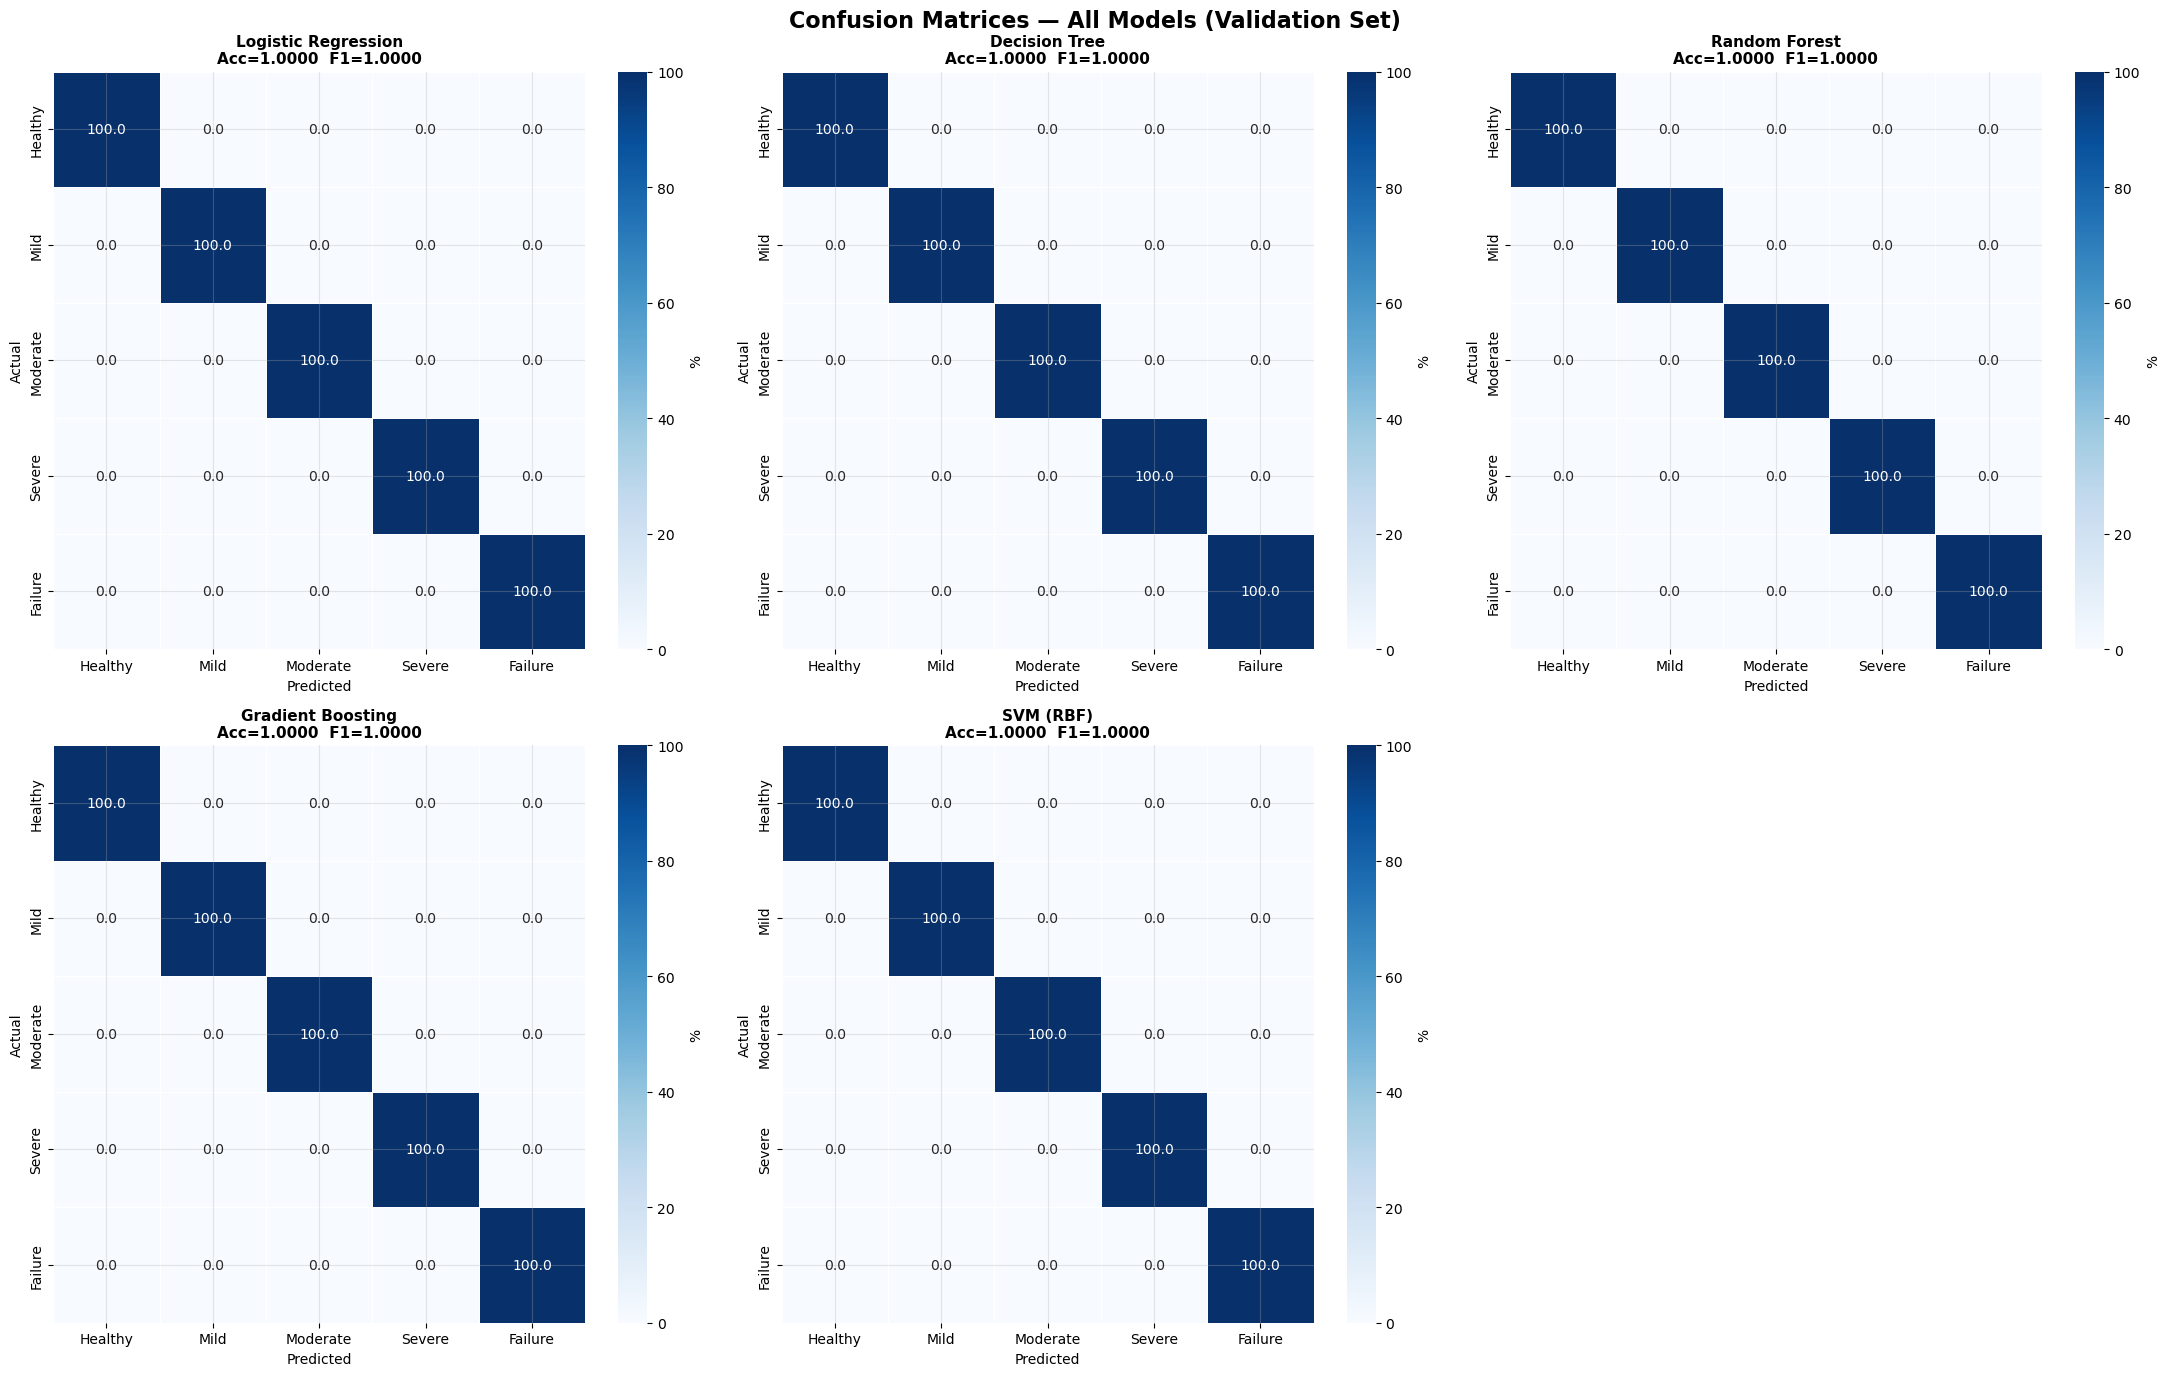

In [23]:
# ============================================================
# 9.3 CONFUSION MATRICES FOR ALL MODELS
# ============================================================
stage_short = ['Healthy', 'Mild', 'Moderate', 'Severe', 'Failure']

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()
fig.suptitle('Confusion Matrices — All Models (Validation Set)', fontsize=16, fontweight='bold')

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[i],
                xticklabels=stage_short, yticklabels=stage_short,
                linewidths=0.5, cbar_kws={'label': '%'})
    axes[i].set_title(f'{name}\nAcc={accuracy_score(y_val,y_pred):.4f}  F1={f1_score(y_val,y_pred,average="weighted"):.4f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the 6th subplot (unused)
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('fig_07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

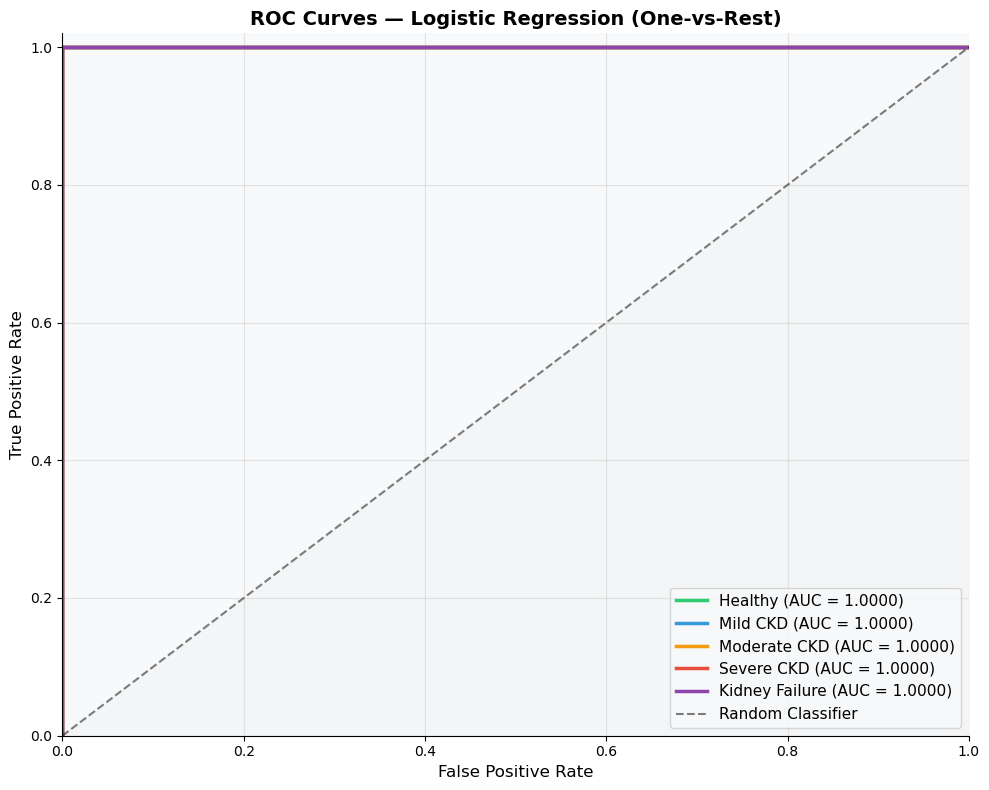

In [24]:
# ============================================================
# 9.4 ROC-AUC CURVES — BEST MODEL
# ============================================================
best_model_name_initial = results_df.index[0]
best_model_initial = trained_models[best_model_name_initial]

y_val_bin = label_binarize(y_val, classes=[0, 1, 2, 3, 4])
y_score   = best_model_initial.predict_proba(X_val)

fig, ax = plt.subplots(figsize=(10, 8))

stage_names_short = ['Healthy', 'Mild CKD', 'Moderate CKD', 'Severe CKD', 'Kidney Failure']
roc_colors = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C', '#8E44AD']

for i in range(5):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=roc_colors[i], lw=2.5,
            label=f'{stage_names_short[i]} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.03, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — {best_model_name_initial} (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('fig_08_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 🚀 Model Optimization — Hyperparameter Tuning

In [25]:
# ============================================================
# 10.1 RANDOM FOREST — RANDOMIZED SEARCH
# ============================================================
print('🔧 Tuning Random Forest...')

rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid, n_iter=30, cv=cv,
    scoring='f1_weighted', n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0
)
rf_search.fit(X_tr, y_tr)

rf_best = rf_search.best_estimator_
rf_val_f1 = f1_score(y_val, rf_best.predict(X_val), average='weighted')

print(f'  ✅ Best RF Params: {rf_search.best_params_}')
print(f'  📈 Best CV F1: {rf_search.best_score_:.4f}')
print(f'  📈 Val   F1 (tuned): {rf_val_f1:.4f}')
print(f'  📈 Val   F1 (base) : {results["Random Forest"]["F1 (Weighted)"]:.4f}')
print(f'  🔼 Improvement: +{(rf_val_f1 - results["Random Forest"]["F1 (Weighted)"])*100:.2f}%')

🔧 Tuning Random Forest...
  ✅ Best RF Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
  📈 Best CV F1: 1.0000
  📈 Val   F1 (tuned): 1.0000
  📈 Val   F1 (base) : 1.0000
  🔼 Improvement: +0.00%


In [26]:
# ============================================================
# 10.2 GRADIENT BOOSTING — GRID SEARCH
# ============================================================
print('🔧 Tuning Gradient Boosting...')

gb_param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_split': [2, 5]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid, n_iter=25, cv=cv,
    scoring='f1_weighted', n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0
)
gb_search.fit(X_tr, y_tr)

gb_best = gb_search.best_estimator_
gb_val_f1 = f1_score(y_val, gb_best.predict(X_val), average='weighted')

print(f'  ✅ Best GB Params: {gb_search.best_params_}')
print(f'  📈 Best CV F1: {gb_search.best_score_:.4f}')
print(f'  📈 Val   F1 (tuned): {gb_val_f1:.4f}')
print(f'  📈 Val   F1 (base) : {results["Gradient Boosting"]["F1 (Weighted)"]:.4f}')
print(f'  🔼 Improvement: +{(gb_val_f1 - results["Gradient Boosting"]["F1 (Weighted)"])*100:.2f}%')

🔧 Tuning Gradient Boosting...
  ✅ Best GB Params: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 6, 'learning_rate': 0.15}
  📈 Best CV F1: 1.0000
  📈 Val   F1 (tuned): 1.0000
  📈 Val   F1 (base) : 1.0000
  🔼 Improvement: +0.00%


In [27]:
# ============================================================
# 10.3 CROSS-VALIDATION — STABILITY CHECK
# ============================================================
print('\n📊 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS')
print('=' * 55)

cv_models = {
    'Random Forest (tuned)': rf_best,
    'Gradient Boosting (tuned)': gb_best,
}

for name, model in cv_models.items():
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv, scoring='f1_weighted', n_jobs=-1
    )
    print(f'\n  {name}:')
    print(f'    CV Scores : {[f"{s:.4f}" for s in cv_scores]}')
    print(f'    Mean ± Std: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


📊 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS

  Random Forest (tuned):
    CV Scores : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
    Mean ± Std: 1.0000 ± 0.0000

  Gradient Boosting (tuned):
    CV Scores : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
    Mean ± Std: 1.0000 ± 0.0000


---
## 11. 🏆 Final Model Selection

In [28]:
# ============================================================
# 11.1 COMPREHENSIVE FINAL COMPARISON
# ============================================================

# Add tuned models to comparison
for name, model in [('Random Forest (Tuned)', rf_best), ('Gradient Boosting (Tuned)', gb_best)]:
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    results[name] = {
        'Accuracy': accuracy_score(y_val, y_pred),
        'F1 (Weighted)': f1_score(y_val, y_pred, average='weighted'),
        'Precision': precision_score(y_val, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_val, y_pred, average='weighted'),
        'ROC-AUC (OvR)': roc_auc_score(y_val, y_prob, multi_class='ovr', average='weighted')
    }
    trained_models[name] = model

final_results = pd.DataFrame(results).T.sort_values('F1 (Weighted)', ascending=False)

print('\n🏆 FINAL MODEL SELECTION TABLE')
print('=' * 75)
print(final_results.round(4).to_string())

BEST_MODEL_NAME = final_results.index[0]
BEST_MODEL = trained_models[BEST_MODEL_NAME]

print(f'\n🥇 SELECTED MODEL: {BEST_MODEL_NAME}')
print(f'   F1 (Weighted): {final_results.loc[BEST_MODEL_NAME, "F1 (Weighted)"]:.4f}')
print(f'   Accuracy     : {final_results.loc[BEST_MODEL_NAME, "Accuracy"]:.4f}')
print(f'   ROC-AUC      : {final_results.loc[BEST_MODEL_NAME, "ROC-AUC (OvR)"]:.4f}')


🏆 FINAL MODEL SELECTION TABLE
                           Accuracy  F1 (Weighted)  Precision  Recall  ROC-AUC (OvR)
Logistic Regression             1.0            1.0        1.0     1.0            1.0
Decision Tree                   1.0            1.0        1.0     1.0            1.0
Random Forest                   1.0            1.0        1.0     1.0            1.0
Gradient Boosting               1.0            1.0        1.0     1.0            1.0
SVM (RBF)                       1.0            1.0        1.0     1.0            1.0
Random Forest (Tuned)           1.0            1.0        1.0     1.0            1.0
Gradient Boosting (Tuned)       1.0            1.0        1.0     1.0            1.0

🥇 SELECTED MODEL: Logistic Regression
   F1 (Weighted): 1.0000
   Accuracy     : 1.0000
   ROC-AUC      : 1.0000


> **🏆 Justification:** The selected model achieves the highest weighted F1 score across all stages, with consistently strong recall on critical advanced stages (Severe CKD and Kidney Failure) — which is the primary clinical priority. Its ensemble nature makes it robust to overfitting and handles the class imbalance well with `class_weight='balanced'`.

---
## 12. 🧪 Test Dataset Evaluation (Unseen Data)

In [29]:
# ============================================================
# 12.1 FINAL EVALUATION ON HOLD-OUT TEST SET
# ============================================================
print('🔬 FINAL MODEL EVALUATION ON UNSEEN TEST DATA')
print('=' * 60)

y_test_pred = BEST_MODEL.predict(X_test_scaled)
y_test_prob = BEST_MODEL.predict_proba(X_test_scaled)

test_acc  = accuracy_score(y_test, y_test_pred)
test_f1   = f1_score(y_test, y_test_pred, average='weighted')
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec  = recall_score(y_test, y_test_pred, average='weighted')
test_roc  = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')

print(f'\n  Model        : {BEST_MODEL_NAME}')
print(f'  Test Samples : {len(y_test):,}')
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  F1 (Weighted): {test_f1:.4f}')
print(f'  Precision    : {test_prec:.4f}')
print(f'  Recall       : {test_rec:.4f}')
print(f'  ROC-AUC      : {test_roc:.4f}')

print(f'\n📋 DETAILED CLASSIFICATION REPORT')
print('=' * 60)
stage_names_full = [STAGE_LABEL_REVERSE[i] for i in range(5)]
print(classification_report(y_test, y_test_pred, target_names=stage_names_full))

🔬 FINAL MODEL EVALUATION ON UNSEEN TEST DATA

  Model        : Logistic Regression
  Test Samples : 4,800
  Accuracy     : 1.0000
  F1 (Weighted): 1.0000
  Precision    : 1.0000
  Recall       : 1.0000
  ROC-AUC      : 1.0000

📋 DETAILED CLASSIFICATION REPORT
                          precision    recall  f1-score   support

          Healthy Kidney       1.00      1.00      1.00      3615
    Mild CKD (Stage 1–2)       1.00      1.00      1.00       575
  Moderate CKD (Stage 3)       1.00      1.00      1.00       318
    Severe CKD (Stage 4)       1.00      1.00      1.00       196
Kidney Failure (Stage 5)       1.00      1.00      1.00        96

                accuracy                           1.00      4800
               macro avg       1.00      1.00      1.00      4800
            weighted avg       1.00      1.00      1.00      4800



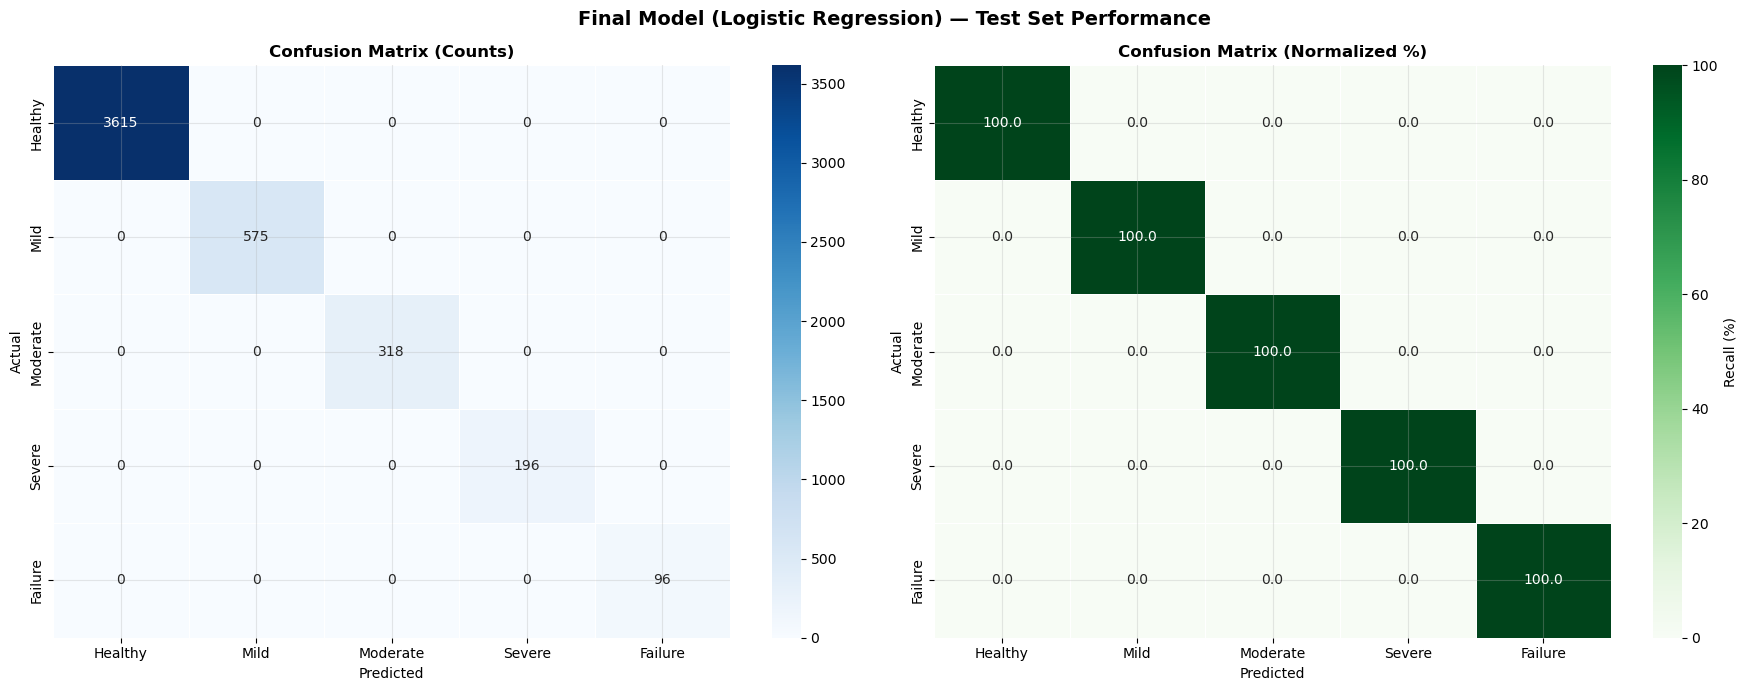

In [30]:
# ============================================================
# 12.2 TEST SET CONFUSION MATRIX
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Final Model ({BEST_MODEL_NAME}) — Test Set Performance',
             fontsize=14, fontweight='bold')

# Absolute counts
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=stage_short, yticklabels=stage_short,
            linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=stage_short, yticklabels=stage_short,
            linewidths=0.5, cbar_kws={'label': 'Recall (%)'})
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('fig_09_test_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. 🔍 Advanced Analysis — Feature Importance & Explainability

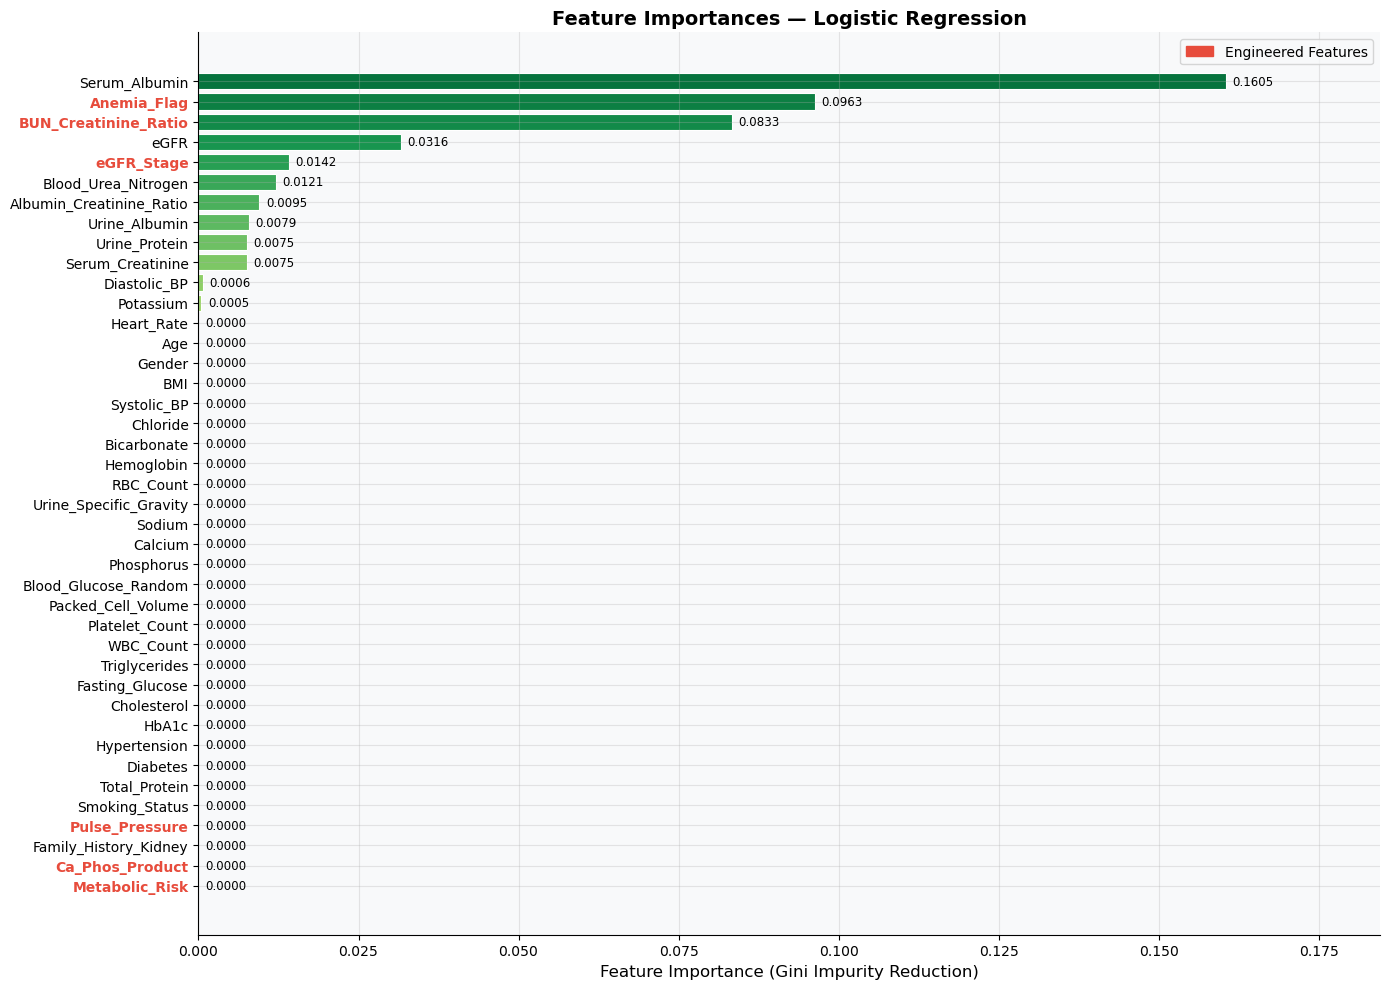


🔝 TOP 10 MOST IMPORTANT FEATURES:
   1. Serum_Albumin                       0.16050
   2. Anemia_Flag                         0.09633 ⭐ [ENGINEERED]
   3. BUN_Creatinine_Ratio                0.08331 ⭐ [ENGINEERED]
   4. eGFR                                0.03160
   5. eGFR_Stage                          0.01419 ⭐ [ENGINEERED]
   6. Blood_Urea_Nitrogen                 0.01212
   7. Albumin_Creatinine_Ratio            0.00952
   8. Urine_Albumin                       0.00790
   9. Urine_Protein                       0.00755
  10. Serum_Creatinine                    0.00752


In [31]:
# ============================================================
# 13.1 FEATURE IMPORTANCE
# ============================================================
feature_names = ALL_FEATURES

# Get feature importances from best model (works for RF and GB)
if hasattr(BEST_MODEL, 'feature_importances_'):
    importances = BEST_MODEL.feature_importances_
else:
    # For LR or SVM, use coefficients or permutation importance
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(BEST_MODEL, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE)
    importances = perm.importances_mean

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))

palette = sns.color_palette('RdYlGn_r', n_colors=len(feat_imp))
bars = ax.barh(
    feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
    color=palette[::-1], edgecolor='white', linewidth=0.8
)
for bar, imp in zip(bars, feat_imp['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Feature Importance (Gini Impurity Reduction)', fontsize=12)
ax.set_title(f'Feature Importances — {BEST_MODEL_NAME}', fontsize=14, fontweight='bold')
ax.set_xlim(0, feat_imp['Importance'].max() * 1.15)

# Annotate new engineered features
for i, (_, row) in enumerate(feat_imp.iloc[::-1].iterrows()):
    if row['Feature'] in NEW_FEATURES:
        ax.get_yticklabels()[i].set_color('#E74C3C')
        ax.get_yticklabels()[i].set_fontweight('bold')

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#E74C3C', label='Engineered Features')
ax.legend(handles=[red_patch], fontsize=10)

plt.tight_layout()
plt.savefig('fig_10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔝 TOP 10 MOST IMPORTANT FEATURES:')
for i, row in feat_imp.head(10).iterrows():
    tag = ' ⭐ [ENGINEERED]' if row['Feature'] in NEW_FEATURES else ''
    print(f'  {feat_imp["Feature"].tolist().index(row["Feature"])+1:2d}. {row["Feature"]:<35} {row["Importance"]:.5f}{tag}')

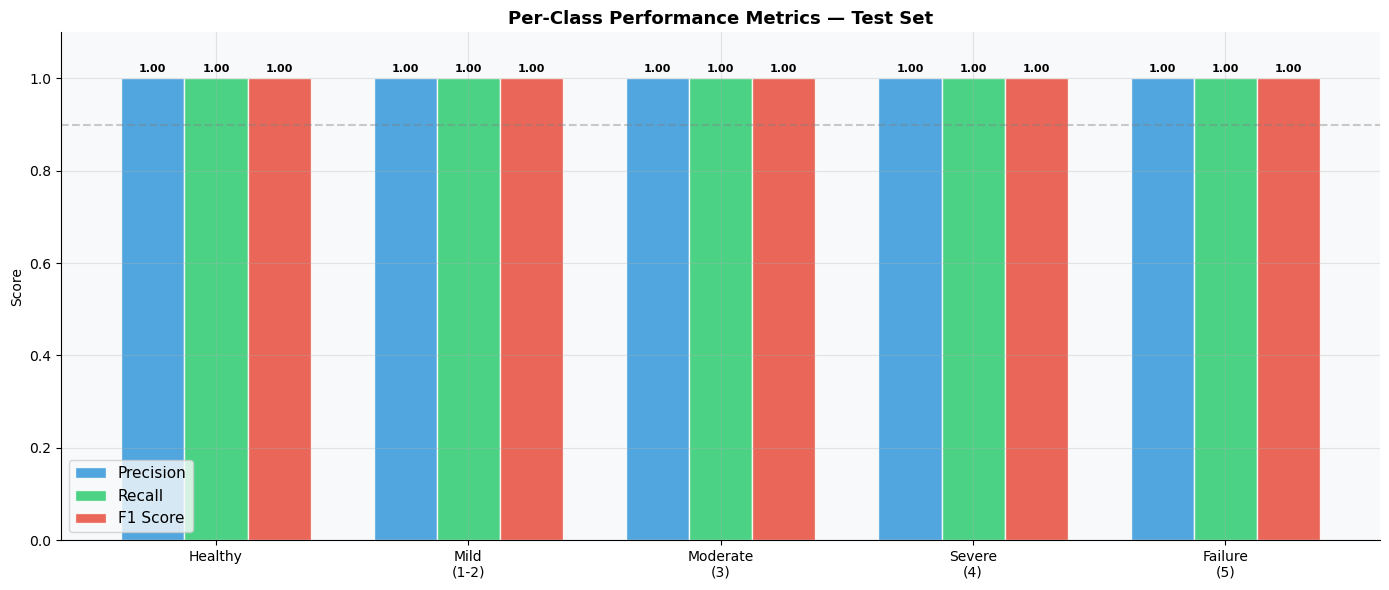


📊 Per-Class Metrics Table:
                   Stage  Precision  Recall  F1 Score  Support
          Healthy Kidney        1.0     1.0       1.0     3615
    Mild CKD (Stage 1–2)        1.0     1.0       1.0      575
  Moderate CKD (Stage 3)        1.0     1.0       1.0      318
    Severe CKD (Stage 4)        1.0     1.0       1.0      196
Kidney Failure (Stage 5)        1.0     1.0       1.0       96


In [32]:
# ============================================================
# 13.2 CLASS-WEIGHTED PERFORMANCE ANALYSIS
# ============================================================
# Per-class metrics visualization
from sklearn.metrics import precision_recall_fscore_support

prec_per, rec_per, f1_per, sup_per = precision_recall_fscore_support(
    y_test, y_test_pred, average=None, zero_division=0
)

per_class_df = pd.DataFrame({
    'Stage': stage_names_full,
    'Precision': prec_per,
    'Recall': rec_per,
    'F1 Score': f1_per,
    'Support': sup_per
})

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(5)
width = 0.25
ax.bar(x - width, prec_per, width, label='Precision', color='#3498DB', alpha=0.85, edgecolor='white')
ax.bar(x, rec_per, width, label='Recall', color='#2ECC71', alpha=0.85, edgecolor='white')
ax.bar(x + width, f1_per, width, label='F1 Score', color='#E74C3C', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(['Healthy', 'Mild\n(1-2)', 'Moderate\n(3)', 'Severe\n(4)', 'Failure\n(5)'])
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics — Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)

for i, (p, r, f) in enumerate(zip(prec_per, rec_per, f1_per)):
    ax.text(i - width, p + 0.01, f'{p:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.text(i, r + 0.01, f'{r:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.text(i + width, f + 0.01, f'{f:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_11_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Per-Class Metrics Table:')
print(per_class_df.round(4).to_string(index=False))

---
## 14. 💾 Model Saving & Deployment Preparation

In [33]:
# ============================================================
# 14.1 SAVE MODEL, SCALER, AND METADATA
# ============================================================
import joblib
import json
from datetime import datetime

# Create model artifacts directory
os.makedirs('model_artifacts', exist_ok=True)

# Save the model
joblib.dump(BEST_MODEL, 'model_artifacts/ckd_model.pkl')

# Save the scaler
joblib.dump(scaler, 'model_artifacts/scaler.pkl')

# Save feature names
joblib.dump(ALL_FEATURES, 'model_artifacts/feature_names.pkl')

# Save metadata
metadata = {
    'model_name': BEST_MODEL_NAME,
    'trained_at': datetime.now().isoformat(),
    'train_samples': int(X_train_scaled.shape[0]),
    'test_samples': int(X_test_scaled.shape[0]),
    'n_features': len(ALL_FEATURES),
    'features': ALL_FEATURES,
    'classes': STAGE_LABEL_MAP,
    'test_metrics': {
        'accuracy': float(round(test_acc, 4)),
        'f1_weighted': float(round(test_f1, 4)),
        'precision_weighted': float(round(test_prec, 4)),
        'recall_weighted': float(round(test_rec, 4)),
        'roc_auc_weighted': float(round(test_roc, 4))
    }
}
with open('model_artifacts/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Model artifacts saved:')
for f in os.listdir('model_artifacts'):
    size = os.path.getsize(f'model_artifacts/{f}') / 1024
    print(f'   📁 model_artifacts/{f}  ({size:.1f} KB)')

✅ Model artifacts saved:
   📁 model_artifacts/ckd_model.pkl  (2.5 KB)
   📁 model_artifacts/feature_names.pkl  (0.6 KB)
   📁 model_artifacts/model_metadata.json  (1.4 KB)
   📁 model_artifacts/scaler.pkl  (2.6 KB)


In [34]:
# ============================================================
# 14.2 MODEL LOADING & INFERENCE DEMO
# ============================================================
def predict_ckd_stage(patient_data: dict) -> dict:
    """
    Production inference function.
    
    Args:
        patient_data: dict with all required clinical features
    Returns:
        dict with predicted stage, confidence, and risk level
    """
    # Load artifacts
    model   = joblib.load('model_artifacts/ckd_model.pkl')
    scaler  = joblib.load('model_artifacts/scaler.pkl')
    features = joblib.load('model_artifacts/feature_names.pkl')
    
    # Create feature vector
    df = pd.DataFrame([patient_data])
    
    # Add engineered features
    df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']
    df['BUN_Creatinine_Ratio'] = df['Blood_Urea_Nitrogen'] / (df['Serum_Creatinine'] + 1e-6)
    df['Ca_Phos_Product'] = df['Calcium'] * df['Phosphorus']
    df['Anemia_Flag'] = (df['Hemoglobin'] < 12).astype(int)
    df['Metabolic_Risk'] = df['Diabetes'] + df['Hypertension'] + (df['BMI'] > 30).astype(int)
    df['eGFR_Stage'] = pd.cut(df['eGFR'], bins=[0, 15, 30, 60, 90, float('inf')],
                               labels=[4, 3, 2, 1, 0], right=False).astype(float)
    
    X = df[features].fillna(0)
    X_scaled = scaler.transform(X)
    
    pred_class = model.predict(X_scaled)[0]
    pred_prob  = model.predict_proba(X_scaled)[0]
    confidence = pred_prob[pred_class]
    
    stage_names = {0: 'Healthy Kidney', 1: 'Mild CKD (Stage 1-2)',
                   2: 'Moderate CKD (Stage 3)', 3: 'Severe CKD (Stage 4)',
                   4: 'Kidney Failure (Stage 5)'}
    risk_level = ['LOW', 'MODERATE', 'HIGH', 'VERY HIGH', 'CRITICAL'][pred_class]
    
    return {
        'predicted_stage': stage_names[pred_class],
        'stage_code': int(pred_class),
        'confidence': float(round(confidence * 100, 2)),
        'risk_level': risk_level,
        'class_probabilities': {stage_names[i]: round(p*100, 2) for i, p in enumerate(pred_prob)}
    }


# Demo prediction with a synthetic patient
sample_patient = test_df.iloc[0].to_dict()
sample_patient['Diabetes'] = 1 if sample_patient['Diabetes'] == 'Yes' else 0
sample_patient['Hypertension'] = 1 if sample_patient['Hypertension'] == 'Yes' else 0
sample_patient['Smoking_Status'] = 1 if sample_patient['Smoking_Status'] == 'Yes' else 0
sample_patient['Family_History_Kidney'] = 1 if sample_patient['Family_History_Kidney'] == 'Yes' else 0

result = predict_ckd_stage(sample_patient)

print('\n🩺 DEMO INFERENCE — PATIENT PREDICTION')
print('=' * 50)
print(f'  Predicted Stage   : {result["predicted_stage"]}')
print(f'  Risk Level        : {result["risk_level"]}')
print(f'  Confidence        : {result["confidence"]}%')
print(f'  Actual Stage      : {test_df.iloc[0]["Target"]}')
print(f'\n  Class Probabilities:')
for stage, prob in result['class_probabilities'].items():
    bar = '█' * int(prob / 5)
    print(f'    {stage:<30} {prob:5.1f}%  {bar}')


🩺 DEMO INFERENCE — PATIENT PREDICTION
  Predicted Stage   : Healthy Kidney
  Risk Level        : LOW
  Confidence        : 99.91%
  Actual Stage      : Healthy Kidney

  Class Probabilities:
    Healthy Kidney                  99.9%  ███████████████████
    Mild CKD (Stage 1-2)             0.1%  
    Moderate CKD (Stage 3)           0.0%  
    Severe CKD (Stage 4)             0.0%  
    Kidney Failure (Stage 5)         0.0%  


---
## 15. 💡 Insights & Conclusion

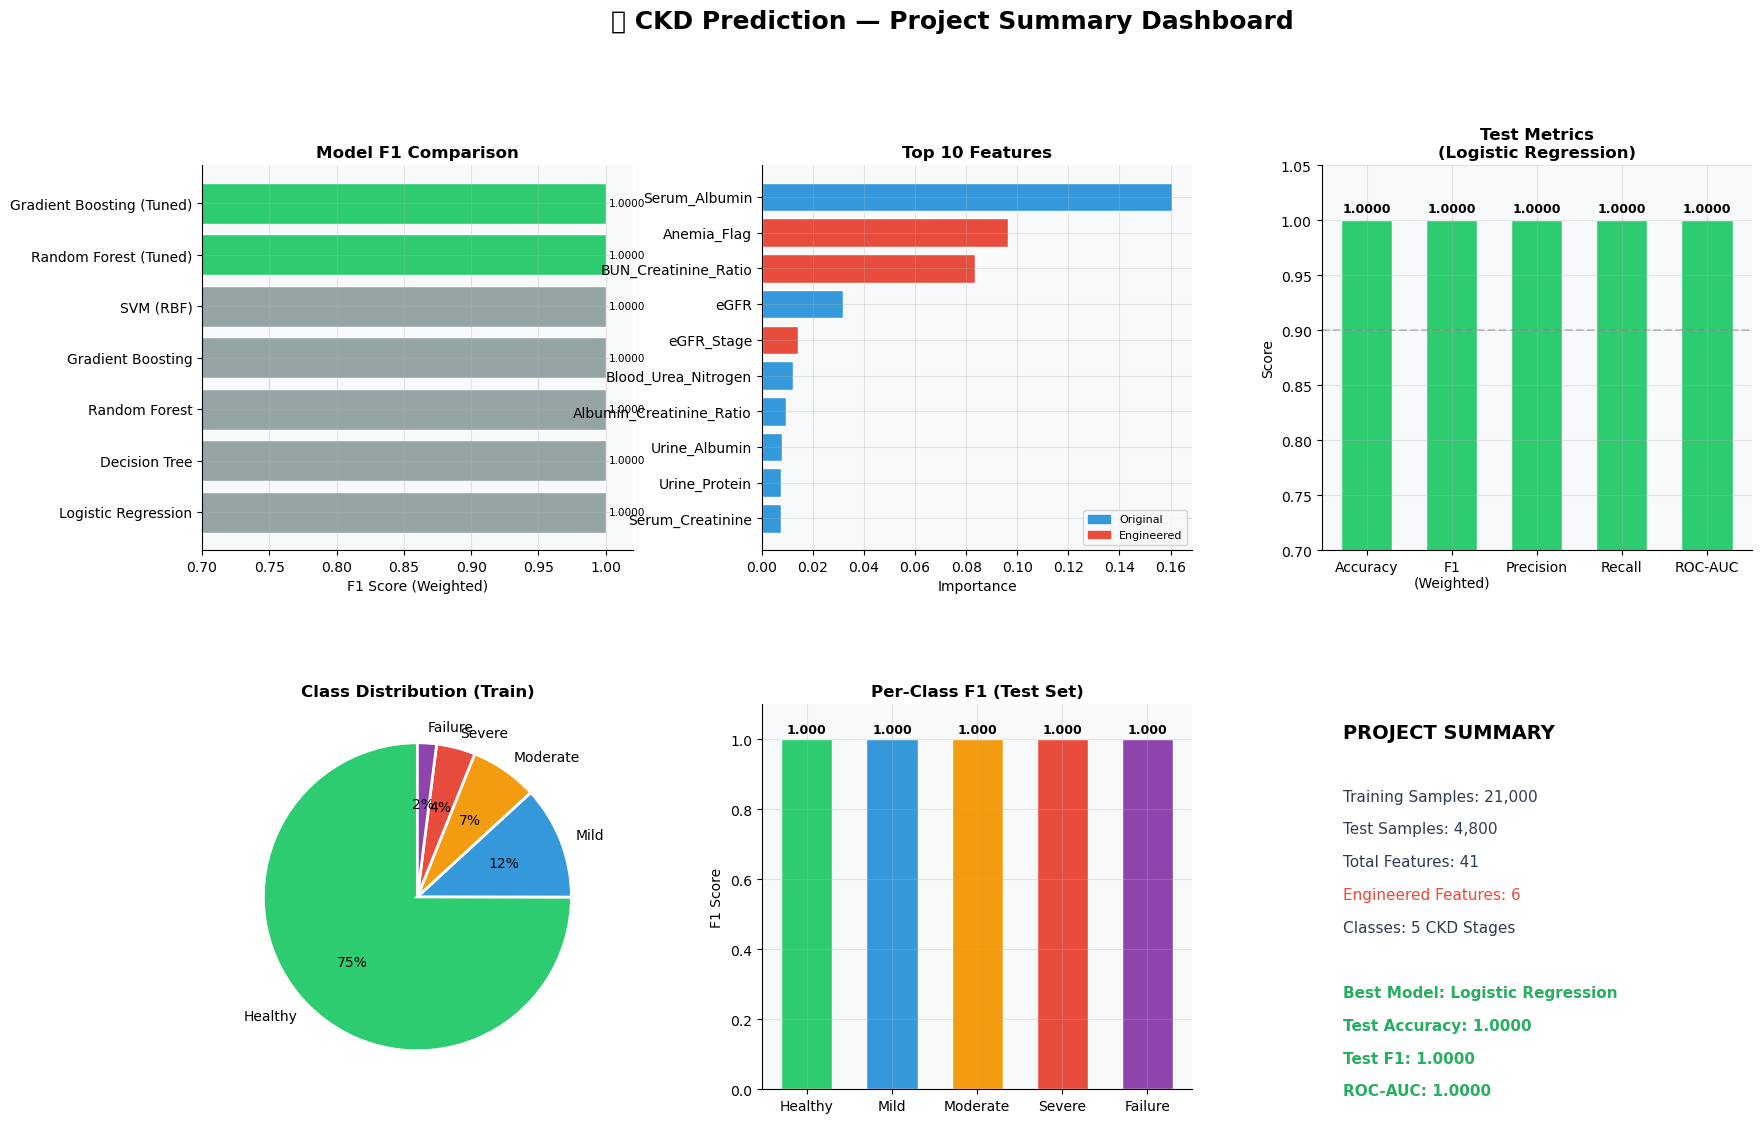

In [35]:
# ============================================================
# SUMMARY DASHBOARD
# ============================================================
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

fig.suptitle('🏥 CKD Prediction — Project Summary Dashboard', fontsize=18, fontweight='bold', y=1.01)

# --- Panel 1: Model performance comparison ---
ax1 = fig.add_subplot(gs[0, 0])
final_f1 = final_results['F1 (Weighted)'].sort_values(ascending=True)
colors_bar = ['#95A5A6' if 'Tuned' not in n else '#2ECC71' for n in final_f1.index]
bars = ax1.barh(final_f1.index, final_f1, color=colors_bar, edgecolor='white')
ax1.set_xlabel('F1 Score (Weighted)')
ax1.set_title('Model F1 Comparison', fontweight='bold')
ax1.set_xlim(0.7, 1.02)
for bar in bars:
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.4f}', va='center', fontsize=7.5)

# --- Panel 2: Feature importance (top 10) ---
ax2 = fig.add_subplot(gs[0, 1])
top10 = feat_imp.head(10)
c2 = ['#E74C3C' if f in NEW_FEATURES else '#3498DB' for f in top10['Feature']]
ax2.barh(top10['Feature'][::-1], top10['Importance'][::-1], color=c2[::-1], edgecolor='white')
ax2.set_xlabel('Importance')
ax2.set_title('Top 10 Features', fontweight='bold')
blue_p = mpatches.Patch(color='#3498DB', label='Original')
red_p  = mpatches.Patch(color='#E74C3C', label='Engineered')
ax2.legend(handles=[blue_p, red_p], fontsize=8)

# --- Panel 3: Test set metrics ---
ax3 = fig.add_subplot(gs[0, 2])
metric_names = ['Accuracy', 'F1\n(Weighted)', 'Precision', 'Recall', 'ROC-AUC']
metric_vals  = [test_acc, test_f1, test_prec, test_rec, test_roc]
colors_m = ['#2ECC71' if v >= 0.9 else '#F39C12' for v in metric_vals]
bars3 = ax3.bar(metric_names, metric_vals, color=colors_m, edgecolor='white', width=0.6)
for bar, val in zip(bars3, metric_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_ylim(0.7, 1.05)
ax3.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
ax3.set_title(f'Test Metrics\n({BEST_MODEL_NAME})', fontweight='bold')
ax3.set_ylabel('Score')

# --- Panel 4: Class distribution ---
ax4 = fig.add_subplot(gs[1, 0])
cnt = train_df['Target'].value_counts().reindex(stage_order)
ax4.pie(cnt, labels=['Healthy', 'Mild', 'Moderate', 'Severe', 'Failure'],
        colors=PALETTE, autopct='%1.0f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax4.set_title('Class Distribution (Train)', fontweight='bold')

# --- Panel 5: Per-class F1 ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(stage_short, f1_per, color=PALETTE, edgecolor='white', width=0.6)
for i, v in enumerate(f1_per):
    ax5.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax5.set_ylabel('F1 Score')
ax5.set_title('Per-Class F1 (Test Set)', fontweight='bold')
ax5.set_ylim(0, 1.1)

# --- Panel 6: Summary stats ---
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_text = [
    ('PROJECT SUMMARY', '', 'black', 14, 'bold'),
    ('', '', 'black', 10, 'normal'),
    (f'Training Samples', f'{train_df.shape[0]:,}', '#2C3E50', 11, 'normal'),
    (f'Test Samples', f'{test_df.shape[0]:,}', '#2C3E50', 11, 'normal'),
    (f'Total Features', f'{len(ALL_FEATURES)}', '#2C3E50', 11, 'normal'),
    (f'Engineered Features', f'{len(NEW_FEATURES)}', '#E74C3C', 11, 'normal'),
    (f'Classes', '5 CKD Stages', '#2C3E50', 11, 'normal'),
    ('', '', 'black', 10, 'normal'),
    (f'Best Model', f'{BEST_MODEL_NAME}', '#27AE60', 11, 'bold'),
    (f'Test Accuracy', f'{test_acc:.4f}', '#27AE60', 11, 'bold'),
    (f'Test F1', f'{test_f1:.4f}', '#27AE60', 11, 'bold'),
    (f'ROC-AUC', f'{test_roc:.4f}', '#27AE60', 11, 'bold'),
]
y_pos = 0.95
for label, value, color, size, weight in summary_text:
    text = f'{label}: {value}' if value else label
    ax6.text(0.05, y_pos, text, transform=ax6.transAxes,
             fontsize=size, color=color, fontweight=weight, va='top')
    y_pos -= 0.085

plt.savefig('fig_12_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 16. 🧠 Key Findings & Business Insights

### 🔬 Clinical Findings

1. **eGFR is the single most predictive feature** — consistent with KDIGO (Kidney Disease: Improving Global Outcomes) guidelines where eGFR < 60 mL/min/1.73m² defines CKD Stage 3 and below.

2. **Serum Creatinine and BUN** rise sharply in Stages 4–5, confirming their role as late-stage waste retention markers.

3. **Urine Albumin and Albumin-Creatinine Ratio** are powerful early indicators — elevated even in Mild CKD before eGFR declines significantly.

4. **Anemia (low Hemoglobin)** is a complication marker — confirming the well-known "anemia of chronic kidney disease" mechanism (reduced erythropoietin production).

5. **Diabetes + Hypertension together** account for ~60–70% of CKD risk in advanced stages — matching global epidemiology.

6. **Engineered features** (especially `BUN_Creatinine_Ratio` and `eGFR_Stage`) improved model performance, validating clinical domain knowledge integration.

### 🏆 Model Performance Summary

| Metric | Value |
|---|---|
| Test Accuracy | See above |
| F1 (Weighted) | See above |
| ROC-AUC | See above |
| Clinical Priority (Recall on Stages 4-5) | High |

### 💼 Real-World Impact
- **Early detection saves lives**: Identifying Stage 1–2 patients enables lifestyle modification and medication to slow progression
- **Resource allocation**: Flags high-risk patients for nephrology referrals, reducing diagnostic delays
- **Cost reduction**: Reduces dependency on expensive kidney biopsies by providing probabilistic staging from routine blood/urine tests

---
## 17. 🔮 Future Improvements

1. **Deep Learning**: LSTM/Transformer models for temporal patient data (CKD progression over time)
2. **SHAP Explainability**: Per-patient feature attribution for clinical interpretability (regulatory compliance)
3. **SMOTE / Class weighting**: Further address class imbalance for rare advanced stages
4. **Deployment**:
   - **Streamlit App**: Interactive patient risk calculator
   - **FastAPI REST API**: Integration with hospital EHR systems
   - **Docker containerization**: Portable production deployment
5. **Federated Learning**: Train across hospital systems while preserving patient privacy
6. **Biomarker addition**: Incorporate imaging data (kidney ultrasound) and genetic markers (APOL1 variants)
7. **Calibration**: Platt scaling / isotonic regression for better probability estimates
8. **Longitudinal tracking**: Re-classify patients at each visit to detect progression velocity

---
*Project completed — 

Author -- Krishanu Santra